# Описание

Я скачал датасет с Kaggle по продажам в e-commerce:\
*Этот набор данных позволяет подробно изучить прибыльность продаж в сфере электронной коммерции. Он содержит данные о различных каналах продаж, включая Shiprocket и INCREFF, а также финансовую информацию о сопутствующих расходах и прибыли. В столбцах содержатся такие данные, как коды SKU, артикулы, уровень запасов, категории товаров, размеры и цвета. В дополнение к этому мы включили MRP для нескольких магазинов, таких как Ajio MRP, Amazon MRP, Amazon FBA MRP, Flipkart MRP, Limeroad MRP, Myntra MRP и Paytm MRP, а также другие ключевые параметры, такие как сумма, уплаченная клиентом за покупку, цена за единицу товара для каждой отдельной транзакции. Кроме того, мы добавили параметры транзакций, такие как дата продажи, категория, статус B2b, количество, валюта, общая сумма. Это обязательный набор данных для всех, кто пытается определить рентабельность продаж в сфере электронной коммерции на современном рынке.*

Рассмотрел данные и решил проанализировать один из датасетов - продажи на Amazon.

<!-- Анализ рентабельности продаж
Цель:
Понять, насколько прибыльны продажи по разным каналам, товарам, категориям и периодам. Выявить, где бизнес зарабатывает больше всего, а где возможны потери.

1. Подготовка данных
Проверить наличие и корректность столбцов: выручка (amount), себестоимость (cost, если есть), расходы (expenses), прибыль (profit).
Если нет явного столбца "прибыль", рассчитать:
прибыль = выручка – себестоимость – расходы
Привести все суммы к одной валюте (если есть разные валюты).
2. Основные показатели рентабельности
Валовая прибыль (Gross Profit):
gross_profit = выручка – себестоимость
Операционная прибыль (Operating Profit):
operating_profit = валовая прибыль – операционные расходы
Рентабельность продаж (ROS, Return on Sales):
ROS = прибыль / выручка * 100%
Рентабельность по категориям/товарам/каналам:
Аналогично, но с группировкой по нужному признаку.
3. Анализ по направлениям
По каналам продаж:
Сравнить рентабельность Amazon, Shiprocket, INCREFF и др.
По категориям товаров:
Найти самые и наименее прибыльные категории.
По времени:
Посмотреть динамику рентабельности по месяцам/неделям.
4. Визуализация
Построить barplot/lineplot по рентабельности в разрезе каналов, категорий, времени.
Построить boxplot по прибыли на заказ.
5. Выявление убыточных направлений
Найти товары/категории/каналы с отрицательной или низкой рентабельностью.
Проанализировать причины (высокая себестоимость, скидки, возвраты и т.д.).
6. Выводы и рекомендации
Где бизнес зарабатывает больше всего?
Какие направления требуют оптимизации?
Как можно повысить общую рентабельность?
Каждый шаг сопровождается расчётами и краткими выводами.
Если нужны формулы для конкретных столбцов — уточните их названия в вашем датасете. -->

Пошаговый план анализа продаж по одному датасету:

Первичный осмотр данных:
- Посмотреть на структуру датасета (колонки, типы данных, пропуски, дубликаты).
- Оценить размер датасета (количество строк и столбцов).

Предобработка:
- Очистить данные: удалить/заменить пропуски, убрать дубликаты.
- Привести названия колонок к единому стилю (snake_case).
- Преобразовать даты в формат datetime.

Описательная статистика:
- Посчитать основные метрики: количество продаж, сумму продаж, средний чек, медиану.
- Посчитать количество уникальных товаров, клиентов, категорий.

Динамика продаж:
- Построить график выручки по месяцам и неделям.
- Построить график количества заказов по времени.
- Посмотреть сезонность (например, по месяцам или дням недели).

Анализ по категориям:
- Топ-10 товаров/категорий по выручке и количеству продаж.
- Построить barplot по категориям.

Анализ по клиентам:
- Посмотреть на распределение продаж на b2b и частных покупателей.

Анализ возвратов/отмен:
- Посчитать долю отменённых/возвращённых заказов.
- Построить график по статусам заказов.

География продаж (если есть данные):
- Топ-10 городов/регионов по выручке.
- Построить карту или barplot.

Проверка гипотез.

In [1]:
# Установка необходимых библиотек
# !pip install kagglehub
# !pip install rapidfuzz

In [2]:
# импортируем библиотеки
import kagglehub
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from rapidfuzz import fuzz, process
from collections import defaultdict
import warnings
from scipy.stats import ttest_ind, levene

In [3]:
# устанавливаем глобальные настройки Pandas (формат вывода и т.д.)
# Настройки Pandas для вывода всех столбцов
pd.set_option('display.max_columns', None)
# Ограничение количества знаков после запятой
pd.set_option('display.float_format', '{:.2f}'.format)
# Ограничение предупреждений о FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("thedevastator/unlock-profits-with-e-commerce-sales-data")

# print("Path to dataset files:", path)

In [5]:
# посмотрим на уже скачанные данные
path1 = r'C:\Users\fedim\.cache\kagglehub\datasets\thedevastator\unlock-profits-with-e-commerce-sales-data\versions\2'
path2 = r'C:\Users\fedotov\.cache\kagglehub\datasets\thedevastator\unlock-profits-with-e-commerce-sales-data\versions\2'

if os.path.exists(path1):
    path = path1
elif os.path.exists(path2):
    path = path2
else:
    raise FileNotFoundError("Ни один из путей не существует.")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\fedim\.cache\kagglehub\datasets\thedevastator\unlock-profits-with-e-commerce-sales-data\versions\2


In [6]:
files = os.listdir(path)
full_paths = [os.path.join(path, file) for file in files]
full_paths

['C:\\Users\\fedim\\.cache\\kagglehub\\datasets\\thedevastator\\unlock-profits-with-e-commerce-sales-data\\versions\\2\\amazon_sale_report.csv',
 'C:\\Users\\fedim\\.cache\\kagglehub\\datasets\\thedevastator\\unlock-profits-with-e-commerce-sales-data\\versions\\2\\cloud_warehouse_compersion_chart.csv',
 'C:\\Users\\fedim\\.cache\\kagglehub\\datasets\\thedevastator\\unlock-profits-with-e-commerce-sales-data\\versions\\2\\expense_iigf.csv',
 'C:\\Users\\fedim\\.cache\\kagglehub\\datasets\\thedevastator\\unlock-profits-with-e-commerce-sales-data\\versions\\2\\international_sale_report.csv',
 'C:\\Users\\fedim\\.cache\\kagglehub\\datasets\\thedevastator\\unlock-profits-with-e-commerce-sales-data\\versions\\2\\may-2022.csv',
 'C:\\Users\\fedim\\.cache\\kagglehub\\datasets\\thedevastator\\unlock-profits-with-e-commerce-sales-data\\versions\\2\\p_l_march_2021.csv',
 'C:\\Users\\fedim\\.cache\\kagglehub\\datasets\\thedevastator\\unlock-profits-with-e-commerce-sales-data\\versions\\2\\sale_repo

In [7]:
files

['amazon_sale_report.csv',
 'cloud_warehouse_compersion_chart.csv',
 'expense_iigf.csv',
 'international_sale_report.csv',
 'may-2022.csv',
 'p_l_march_2021.csv',
 'sale_report.csv']

In [8]:
import re

# Загрузка и предобработка данных

In [9]:
def load_and_inspect(file_path, date_column=None, date_format=None, sep=',', index_col=None, dtype=None):
    """
    Загружает данные из CSV, отображает их содержимое, информацию, пропуски и дубликаты.

    Parameters:
    -----------
    file_path : str
        Путь к CSV-файлу.
    date_column : str, optional
        Название столбца с датами. Если указано, преобразует его в datetime.
    date_format : str, optional
        Формат даты, если она записана нестандартно (например, '%Y%m%d%H').
    sep : str, optional, default ','
        Разделитель в CSV-файле.
    index_col : int or str, optional, default None
        Столбец для использования в качестве индекса. Передай номер колонки или имя.
        Если None — индекс создаётся автоматически.

    Returns:
    --------
    pd.DataFrame
        Загруженный и обработанный датафрейм.
    """
    
    # Загружаем данные из CSV с указанием столбца индекса (если передан)
    data = pd.read_csv(file_path, sep=sep, index_col=index_col, dtype=dtype)
    
    def clean_column_name(name):
        """
        Очистка имени столбца:
        - убираем пробелы в начале/конце
        - приводим к нижнему регистру
        - заменяем дефисы на подчеркивания
        - заменяем пробелы внутри на подчеркивания
        """
        cleaned = name.strip().lower().replace("-", "_")
        cleaned = re.sub(r'\s+', '_', cleaned)
        return cleaned
    
    # Приводим все имена столбцов к единому виду (snake_case)
    data.columns = [clean_column_name(col) for col in data.columns]
    
    # Обработка столбца с датами, если передан
    if date_column:
        date_column_clean = clean_column_name(date_column)
        if date_column_clean in data.columns:
            if date_format:
                data[date_column_clean] = pd.to_datetime(data[date_column_clean], format=date_format)
            else:
                data[date_column_clean] = pd.to_datetime(data[date_column_clean])
        else:
            print(f"⚠️ Внимание: столбец '{date_column}' не найден после очистки имен (ищем '{date_column_clean}')")
    
    # Отображаем первые строки датафрейма
    print('📄 Данные:')
    display(data)
    
    # Общая информация о датафрейме: типы, количество не-null и т.п.
    print('\nℹ️ Общая информация:')
    data.info()
    
    # Количество пропущенных значений по столбцам
    print('\n🕳️ Количество пропусков:')
    print(data.isna().sum())
    
    # Количество дубликатов строк
    print('\n📛 Количество дубликатов:')
    print(data.duplicated().sum())
    
    # Если есть дата, выводим минимальную и максимальную
    if date_column and date_column_clean in data.columns:
        min_date = data[date_column_clean].min()
        max_date = data[date_column_clean].max()
        print(f'\n🗓️ Минимальная дата в столбце "{date_column_clean}": {min_date}')
        print(f'🗓️ Максимальная дата в столбце "{date_column_clean}": {max_date}')
    
    return data

Нас не устраивают имена файлов, с лишними пробелами, с разным регистром.

In [10]:
# Получаем список только файлов (без папок)
files = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]

# Переименование
for old_name in files:
    # Очистка и преобразование:
    # 1. strip() — убрать пробелы в начале и в конце
    # 2. lower() — все строчные
    # 3. re.sub(r"\s+", "_", ...) — заменить любые пробельные символы на _
    new_name = re.sub(r"\s+", "_", old_name.strip().lower())

    old_path = os.path.join(path, old_name)
    new_path = os.path.join(path, new_name)

    if old_path != new_path:
        os.rename(old_path, new_path)
        print(f"Переименовано: '{old_name}' -> '{new_name}'")
# Обновляем список файлов после переименования
files = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]

# Создаем список с полными путями к файлам
file_paths = [os.path.join(path, f) for f in files]

# Выводим общее количество и примеры
print(f"Файлов найдено: {len(file_paths)}")

Файлов найдено: 7


In [11]:
files

['amazon_sale_report.csv',
 'cloud_warehouse_compersion_chart.csv',
 'expense_iigf.csv',
 'international_sale_report.csv',
 'may-2022.csv',
 'p_l_march_2021.csv',
 'sale_report.csv']

## amazon_sale_report

Загрузим первый датасет

In [12]:
amazon_sale_report = load_and_inspect(file_paths[0], date_column='date', index_col='index', dtype={'ship-postal-code': str})

📄 Данные:


C:\Users\fedim\AppData\Local\Temp\ipykernel_23120\2804969997.py:26: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path, sep=sep, index_col=index_col, dtype=dtype)
C:\Users\fedim\AppData\Local\Temp\ipykernel_23120\2804969997.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[date_column_clean] = pd.to_datetime(data[date_column_clean])


,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,unnamed:_22
index,,,,,,,,,,,,,,,,,,,,,,,
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128970,406-6001380-7673107,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,JNE3697,JNE3697-KR-XL,kurta,XL,B098112V2V,Shipped,1,INR,517.00,HYDERABAD,TELANGANA,500013.0,IN,NaN,False,NaN,False
128971,402-9551604-7544318,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,SET401,SET401-KR-NP-M,Set,M,B09VC6KHX8,Shipped,1,INR,999.00,GURUGRAM,HARYANA,122004.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
128972,407-9547469-3152358,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,J0157,J0157-DR-XXL,Western Dress,XXL,B0982YZ51B,Shipped,1,INR,690.00,HYDERABAD,TELANGANA,500049.0,IN,NaN,False,NaN,False



ℹ️ Общая информация:
<class 'pandas.core.frame.DataFrame'>
Index: 128975 entries, 0 to 128974
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            128975 non-null  object        
 1   date                128975 non-null  datetime64[ns]
 2   status              128975 non-null  object        
 3   fulfilment          128975 non-null  object        
 4   sales_channel       128975 non-null  object        
 5   ship_service_level  128975 non-null  object        
 6   style               128975 non-null  object        
 7   sku                 128975 non-null  object        
 8   category            128975 non-null  object        
 9   size                128975 non-null  object        
 10  asin                128975 non-null  object        
 11  courier_status      122103 non-null  object        
 12  qty                 128975 non-null  int64         
 13  currency    

Мы получили данные о продажах в Amazon
- **order_id** — уникальный идентификатор заказа. Тип: `object` (строка).
- **date** — дата совершения продажи. Тип: `datetime64[ns]`.
- **status** — статус заказа (например, `Shipped`, `Cancelled`). Тип: `object`.
- **fulfilment** — способ исполнения заказа (`Merchant`, `Amazon` и др.). Тип: `object`.
- **sales_channel** — канал продаж (например, `Amazon.com`). Тип: `object`.
- **ship_service_level** — уровень сервиса доставки (например, `Standard`, `Expedited`). Тип: `object`.
- **style** — стиль или модель товара. Тип: `object`.
- **sku** — артикул товара (SKU — Stock Keeping Unit), внутренний идентификатор хранения. Тип: `object`.
- **category** — категория товара. Тип: `object`.
- **size** — размер товара. Тип: `object`.
- **asin** — стандартный идентификатор товара в системе Amazon (ASIN — Amazon Standard Identification Number). Тип: `object`.
- **courier_status** — статус доставки (например, `Delivered`, `In Transit`). Может содержать пропущенные значения. Тип: `object`.
- **qty** — количество проданных единиц товара в заказе. Тип: `int64`.
- **currency** — валюта продажи (например, `USD`, `EUR`). Может содержать пропущенные значения. Тип: `object`.
- **amount** — сумма продажи в указанной валюте. Может содержать пропущенные значения. Тип: `float64`.
- **ship_city** — город доставки. Может содержать пропущенные значения. Тип: `object`.
- **ship_state** — штат или регион доставки. Может содержать пропущенные значения. Тип: `object`.
- **ship_postal_code** — почтовый индекс места доставки. Может содержать пропущенные значения. Тип: `object`.
- **ship_country** — страна доставки. Может содержать пропущенные значения. Тип: `object`.
- **promotion_ids** — идентификаторы применённых акций или промо-кодов. Может содержать пропущенные значения. Тип: `object`.
- **b2b** — признак, указывающий на продажу для бизнеса (B2B). Тип: `bool`.
- **fulfilled_by** — указание, кем был исполнен заказ (например, `Amazon`, `Merchant`). Может содержать пропущенные значения. Тип: `object`.
- **unnamed:_22** — дополнительный столбец, возможно, появившийся из-за особенностей импорта (например, лишняя запятая в CSV). Может содержать пропущенные значения. Тип: `object`.

В данных присутствуют дубликаты, на 7000 строк отсутствуют данные о сумме продаж.

### Типы данных и их преобразование

#### Почтовый индекс места доставки [`ship_postal_code`]

Почтовый код указан с **.0** в конце. Уберём их.

In [13]:
# Удаляем '.0' в конце, если есть, и пробелы
amazon_sale_report['ship_postal_code'] = (
    amazon_sale_report['ship_postal_code']
    .astype(str)  # на всякий случай
    .str.strip()
    .str.replace(r'\.0$', '', regex=True)
)

In [14]:
# Проверим тип и несколько уникальных значений
print(amazon_sale_report['ship_postal_code'].dtype)
print(sorted(amazon_sale_report['ship_postal_code'].unique())[:10])  # первые 10 уникальных значений

object
['110001', '110002', '110003', '110004', '110005', '110006', '110007', '110008', '110009', '110010']


### Проверка дубликатов

Проверим на явные и неявные дубликаты

In [15]:
def find_duplicates(df, subset=None, mode='dataframe'):
    """
    Ищет дубликаты в датафрейме.

    Аргументы:
    - df: DataFrame — исходные данные.
    - subset: list | None — список столбцов для проверки (если None, проверяются все).
    - mode: str — 'dataframe' (возвращает строки с дубликатами) или 'count' (возвращает их количество).

    Возвращает:
    - Если mode='dataframe' → датафрейм с дубликатами.
    - Если mode='count' → количество дубликатов.
    """
    # Проверяем на явные дубликаты (по всем колонкам)
    exact_duplicates = df.duplicated().sum()

    # Если subset указан, обрабатываем текстовые столбцы
    if subset:
        temp_df = df.copy()
        transformed_cols = []
        
        for col in subset:
            if temp_df[col].dtype == 'object':  # Только для строковых столбцов
                new_col = col + '_lower'
                temp_df[new_col] = (temp_df[col]
                                    .str.lower()
                                    .str.replace('ё', 'е', regex=True)
                                    .str.replace(r'\b&\b', 'and', regex=True)  # Замена & на and
                                    .str.replace(r'\s+', ' ', regex=True)  # Удаление двойных пробелов
                                    .str.strip())  # Удаление пробелов в начале и конце
                transformed_cols.append(new_col)
            else:
                transformed_cols.append(col)

        # Находим дубликаты по измененным столбцам
        duplicate_rows = temp_df.duplicated(subset=transformed_cols, keep=False)
    else:
        # Если subset не указан, ищем дубликаты по всем колонкам
        duplicate_rows = df.duplicated(keep=False)

    if mode == 'count':
        return f'Явных дубликатов: {exact_duplicates}, Дубликатов по указанным столбцам: {duplicate_rows.sum()}'
    
    print(f'Явных дубликатов: {exact_duplicates}, Дубликатов по указанным столбцам: {duplicate_rows.sum()}')
    return df.loc[duplicate_rows]  # Датафрейм с дубликатами

Проверим по заказам, товарам и странам. Статус заказа может быть разным, а заказ один.

In [16]:
subset = ['order_id', 'sales_channel', 'sku', 'category', 'ship_postal_code']

find_duplicates(amazon_sale_report, subset=subset, mode='count')

'Явных дубликатов: 6, Дубликатов по указанным столбцам: 14'

Мы нашли несколько дубликатов.\
Посмотрим, что они из себя представляют.

In [17]:
# сохраним дубликаты в df
dupl_df = find_duplicates(amazon_sale_report, subset=subset)

# выведем 25 строк
dupl_df.sort_values(by='order_id')

Явных дубликатов: 6, Дубликатов по указанным столбцам: 14


,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,unnamed:_22
index,,,,,,,,,,,,,,,,,,,,,,,
85790,171-3249942-2207542,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,SET323,SET323-KR-NP-XL,Set,XL,B09NDKKM7P,Shipped,1,INR,939.00,PUNE,MAHARASHTRA,411057,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
85791,171-3249942-2207542,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,SET323,SET323-KR-NP-XL,Set,XL,B09NDKKM7P,Shipped,1,INR,939.00,PUNE,MAHARASHTRA,411057,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
79844,171-9628368-5329958,2022-05-07,Cancelled,Amazon,Amazon.in,Expedited,J0329,J0329-KR-L,kurta,L,B09KXRB7JV,Cancelled,0,NaN,NaN,ERNAKULAM,KERALA,682017,IN,NaN,False,NaN,False
79845,171-9628368-5329958,2022-05-07,Cancelled,Amazon,Amazon.in,Expedited,J0329,J0329-KR-L,kurta,L,B09KXRB7JV,Cancelled,0,NaN,NaN,ERNAKULAM,KERALA,682017,IN,NaN,False,NaN,False
86418,405-8669298-3850736,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,MEN5025,MEN5025-KR-XXXL,kurta,3XL,B08YYQS8FH,Shipped,1,INR,533.00,GHAZIABAD,UTTAR PRADESH,201010,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
86419,405-8669298-3850736,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,MEN5025,MEN5025-KR-XXXL,kurta,3XL,B08YYQS8FH,Shipped,1,INR,533.00,GHAZIABAD,UTTAR PRADESH,201010,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
30660,406-0372545-6086735,2022-04-12,Cancelled,Amazon,Amazon.in,Expedited,SET197,SET197-KR-NP-L,Set,L,B08B3YPD63,Cancelled,0,NaN,NaN,Siliguri,WEST BENGAL,734008,IN,NaN,False,NaN,NaN
30661,406-0372545-6086735,2022-04-12,Cancelled,Amazon,Amazon.in,Expedited,SET197,SET197-KR-NP-L,Set,L,B08B3YPD63,Cancelled,0,NaN,NaN,Siliguri,WEST BENGAL,734008,IN,NaN,False,NaN,NaN
98954,407-4853873-4978725,2022-06-22,Shipped,Amazon,Amazon.in,Expedited,J0230,J0230-SKD-M,Set,M,B08XNJG8B1,Shipped,1,INR,1163.00,Zirakpur,Punjab,140603,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False


In [18]:
print(f"Посмотрим на дубликаты по заказу {dupl_df.iloc[-4]['order_id']}:")
amazon_sale_report.loc[amazon_sale_report['order_id'] == dupl_df.iloc[0]['order_id']]

Посмотрим на дубликаты по заказу 405-8669298-3850736:


,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,unnamed:_22
index,,,,,,,,,,,,,,,,,,,,,,,
30660,406-0372545-6086735,2022-04-12,Cancelled,Amazon,Amazon.in,Expedited,SET197,SET197-KR-NP-L,Set,L,B08B3YPD63,Cancelled,0,NaN,NaN,Siliguri,WEST BENGAL,734008,IN,NaN,False,NaN,NaN
30661,406-0372545-6086735,2022-04-12,Cancelled,Amazon,Amazon.in,Expedited,SET197,SET197-KR-NP-L,Set,L,B08B3YPD63,Cancelled,0,NaN,NaN,Siliguri,WEST BENGAL,734008,IN,NaN,False,NaN,NaN


Мы видем, что строки повторяются, мы не можем однозначно определить, почему строки задвоились, 

In [19]:
# убираем дубликаты по указанным столбцам, обновляем индексы
amazon_sale_clean = amazon_sale_report.drop_duplicates(
    subset=subset,
    keep='last').reset_index(drop = True)

### Пропуски

#### Сумма покупки ['amount']

В данных большое количество строк без указания суммы покупки. В целях нашего исследования они не нужны.

In [20]:
# убираем строки с пропусками в сумме заказа
amazon_sale_clean = amazon_sale_clean.dropna(subset=['amount'])

#### Статус курьера ['courier_status']

Было большое количество строк без указания статуса курьера.\
Посмотрим, остались ли они, и сколько.

In [21]:
# отфильтровали строки с пропусками курьеров и посчитали
amazon_sale_clean.loc[amazon_sale_clean['courier_status'].isna()].isna().sum()

order_id                 0
date                     0
status                   0
fulfilment               0
sales_channel            0
ship_service_level       0
style                    0
sku                      0
category                 0
size                     0
asin                     0
courier_status        5136
qty                      0
currency                 0
amount                   0
ship_city                3
ship_state               3
ship_postal_code         0
ship_country             3
promotion_ids         5136
b2b                      0
fulfilled_by             0
unnamed:_22           2129
dtype: int64

Посмотрим, какое количество пропусков в случае, если статус заказа "Отменён"

In [22]:
# фильтруем отмененные заказы, считаем пропуски
amazon_sale_clean.loc[amazon_sale_clean['status']=='Cancelled'].isna().sum()

order_id                  0
date                      0
status                    0
fulfilment                0
sales_channel             0
ship_service_level        0
style                     0
sku                       0
category                  0
size                      0
asin                      0
courier_status         5136
qty                       0
currency                  0
amount                    0
ship_city                 5
ship_state                5
ship_postal_code          0
ship_country              5
promotion_ids         10740
b2b                       0
fulfilled_by           5630
unnamed:_22            4226
dtype: int64

Выходит, что пропуски статуса курьерской доставки у нас в заказах, которые были отменены.\
Можем заменить пропуски на отмена заказа.

In [23]:
# Заменим пропуски в курьере на заказ отменен
amazon_sale_clean['courier_status'] = amazon_sale_clean['courier_status'].fillna('Cancelled')

#### Город, штат, страна

У нас 33 строки с пропусками, посмотрим на них

In [24]:
# Выведем строки с пропусками в городе
amazon_sale_clean.loc[amazon_sale_clean['ship_city'].isna()]

,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,unnamed:_22
1871,404-0566904-4825137,2022-04-29,Shipped,Amazon,Amazon.in,Expedited,J0301,J0301-TP-L,Top,L,B099S6795L,Shipped,1,INR,493.00,NaN,NaN,nan,NaN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
1872,404-0566904-4825137,2022-04-29,Shipped,Amazon,Amazon.in,Expedited,JNE3697,JNE3697-KR-L,kurta,L,B09811Y7WM,Shipped,1,INR,458.00,NaN,NaN,nan,NaN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
8752,406-4003386-8768363,2022-04-25,Shipped,Amazon,Amazon.in,Expedited,JNE3376,JNE3376-KR-M,kurta,M,B082W7HW86,Shipped,1,INR,432.00,NaN,NaN,nan,NaN,NaN,False,NaN,NaN
11215,402-0107720-7057168,2022-04-23,Shipped,Amazon,Amazon.in,Expedited,J0003,J0003-SET-S,Set,S,B0894X27FC,Shipped,1,INR,654.00,NaN,NaN,nan,NaN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
13252,407-4532637-8415521,2022-04-22,Cancelled,Merchant,Amazon.in,Standard,JNE3405,JNE3405-KR-S,kurta,S,B081WX4G4Q,Cancelled,0,INR,380.00,NaN,NaN,nan,NaN,NaN,False,Easy Ship,NaN
15688,404-9229894-8608305,2022-04-21,Shipped,Amazon,Amazon.in,Expedited,JNE3510,JNE3510-KR-M,kurta,M,B08WPR5MCB,Shipped,1,INR,442.00,NaN,NaN,nan,NaN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
16787,402-4919636-4333150,2022-04-20,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE1233,JNE1233-BLUE-KR-031-XXXL,kurta,3XL,B07GPGP46N,Shipped,1,INR,376.00,NaN,NaN,nan,NaN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
18351,405-4927647-8064368,2022-04-19,Shipped,Amazon,Amazon.in,Expedited,J0230,J0230-SKD-XS,Set,XS,B08XNHXSFZ,Shipped,1,INR,1112.00,NaN,NaN,nan,NaN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
22930,402-8628677-0457954,2022-04-16,Shipped - Returned to Seller,Merchant,Amazon.in,Standard,J0003,J0003-SET-S,Set,S,B0894X27FC,Shipped,1,INR,654.00,NaN,NaN,nan,NaN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
24986,406-4079063-8291520,2022-04-15,Cancelled,Amazon,Amazon.in,Expedited,JNE3567,JNE3567-KR-XXL,kurta,XXL,B08KRYCC8J,Unshipped,1,INR,399.00,NaN,NaN,nan,NaN,NaN,False,NaN,NaN


Количество пропусков невелико. Для целей нашего исследования их потеря некритична.\
Заполнение средним, медианой или подобным не представляется возможным. Убираем.

In [25]:
# убираем строки с пропусками в городе доставки
amazon_sale_clean = amazon_sale_clean.dropna(subset=['ship_city'])

#### Примененные акции и промокоды ['promotion_ids']

In [26]:
# Посмотрим, какие маркетинговые акции есть в датасете
print(f"Всего уникальных акций: {amazon_sale_clean['promotion_ids'].nunique()}")

Всего уникальных акций: 5787


5787 маркетинговых акций.

In [27]:
# Посмотрим 10 самых популярных акций
print("Топ-10 акций по количеству:")
amazon_sale_clean['promotion_ids'].value_counts(dropna=True).head(10)

Топ-10 акций по количеству:


promotion_ids
IN Core Free Shipping 2015/04/08 23-48-5-108                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

Акции практически не читаются. Мы видим, что более 45 тысяч раз воспользовались промокодом на бесплатную доставку от Amazon.

В остальных случаях использовалась комбинация промокодов. Таких комбинаций существенно меньше, 500 раз, 400 и менее по каждой комбинации.

Заполним пропуски в столбце `promotion_ids` значением *`No Promo`*.


In [28]:
# Создадим новый столбец для статуса промо-акции
# Если promotion_ids не пустой, то промо применено, иначе без промо
amazon_sale_clean['promotion_status'] = amazon_sale_clean['promotion_ids'].apply(
    lambda x: 'Промо применено' if pd.notna(x) else 'Без промо'
)


#### Остальные столбцы


Уберем `fulfilled_by`, `unnamed:_22`. 

In [29]:
# Уберем столбцы `fulfilled_by`, `unnamed:_22`
amazon_sale_clean = amazon_sale_clean.drop(columns=['fulfilled_by', 'unnamed:_22'], errors='ignore')

Посмотрим, что у нас в итоге с пропусками

In [30]:
# Посмотрим на количество пропусков в датасете после очистки

amazon_sale_clean.isna().sum()

order_id                  0
date                      0
status                    0
fulfilment                0
sales_channel             0
ship_service_level        0
style                     0
sku                       0
category                  0
size                      0
asin                      0
courier_status            0
qty                       0
currency                  0
amount                    0
ship_city                 0
ship_state                0
ship_postal_code          0
ship_country              0
promotion_ids         41691
b2b                       0
promotion_status          0
dtype: int64

In [31]:
# Посмотрим на информацию о датафрейме
amazon_sale_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 121146 entries, 0 to 128967
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            121146 non-null  object        
 1   date                121146 non-null  datetime64[ns]
 2   status              121146 non-null  object        
 3   fulfilment          121146 non-null  object        
 4   sales_channel       121146 non-null  object        
 5   ship_service_level  121146 non-null  object        
 6   style               121146 non-null  object        
 7   sku                 121146 non-null  object        
 8   category            121146 non-null  object        
 9   size                121146 non-null  object        
 10  asin                121146 non-null  object        
 11  courier_status      121146 non-null  object        
 12  qty                 121146 non-null  int64         
 13  currency            121146 non-nul

### Аномалии

Посмотрим на значения в столбцах.

In [32]:
# Посмотрим, какие значения есть в столбцах
amazon_sale_clean.apply(pd.unique).to_frame(name='Unique Values')

,Unique Values
order_id,"[405-8078784-5731545, 171-9198151-1101146, 404..."
date,"[2022-04-30T00:00:00.000000000, 2022-04-29T00:..."
status,"[Cancelled, Shipped - Delivered to Buyer, Ship..."
fulfilment,"[Merchant, Amazon]"
sales_channel,[Amazon.in]
ship_service_level,"[Standard, Expedited]"
style,"[SET389, JNE3781, JNE3371, J0341, JNE3671, SET..."
sku,"[SET389-KR-NP-S, JNE3781-KR-XXXL, JNE3371-KR-X..."
category,"[Set, kurta, Western Dress, Top, Ethnic Dress,..."
size,"[S, 3XL, XL, L, XXL, XS, 6XL, M, 4XL, 5XL, Free]"


В глаза бростается количество товара `qty` 0. Также можно посмотреть на сумму стоимости `amount`.

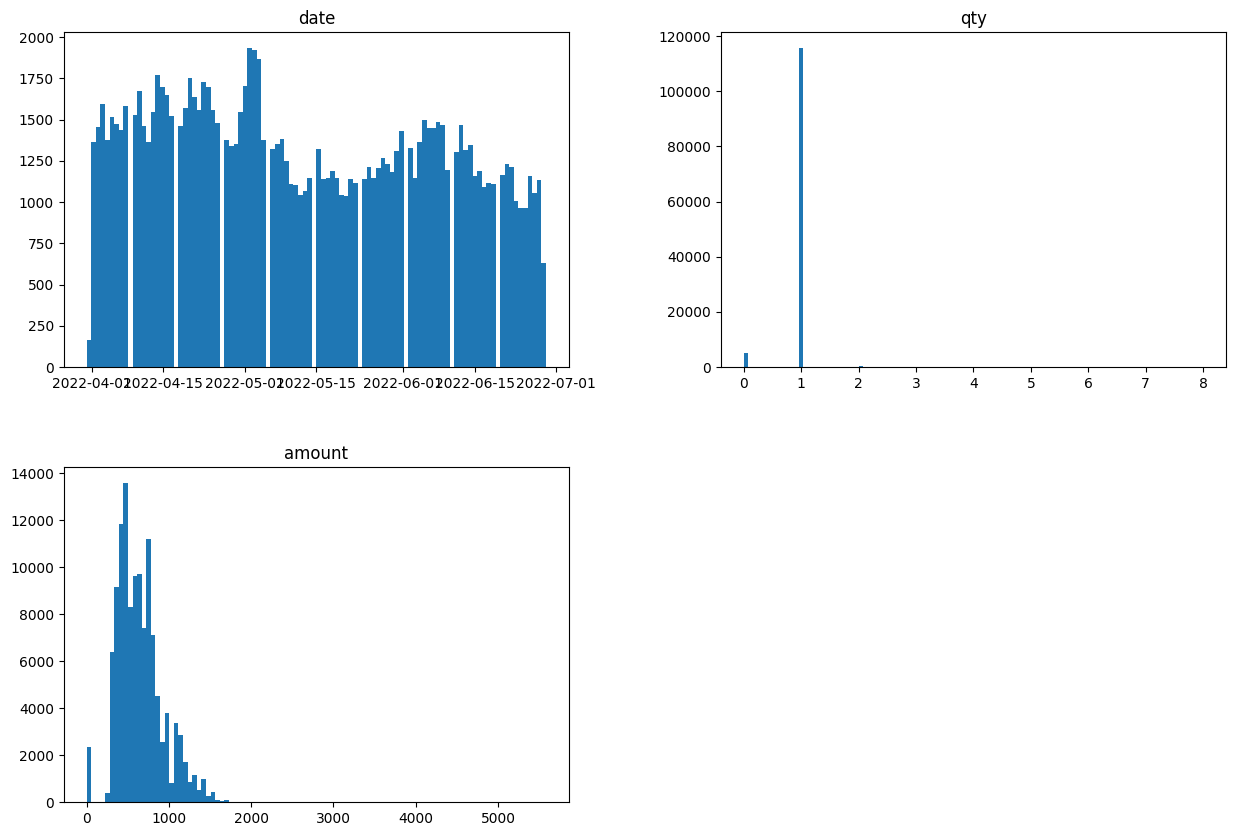

In [33]:
amazon_sale_clean.hist(
    figsize=(15, 10),
    bins=100,
    grid=False,
    layout=(2, 2),
    sharex=False,
    sharey=False
);

- Мы видим, что в датах есть равномерные промежутки: выходные либо дело в масштабе.
- Присутствуют значения 0 количествах. Нужно проверить, не отмененные ли это заказы.
- В суммах значительное количество (почти 2%) значений равны 0.

#### Сумма покупки [`amount`]

Проверим аномальные значения в столбце `amount` (сумма за товар):

count   121146.00
mean       648.57
std        281.22
min          0.00
25%        449.00
50%        605.00
75%        788.00
max       5584.00
Name: amount, dtype: float64

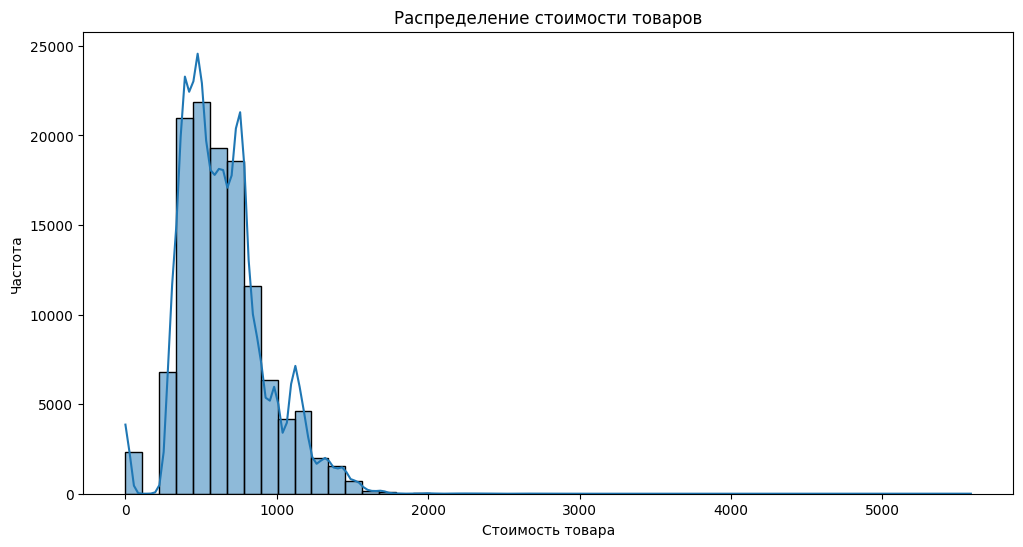

In [34]:
# Посмотрим на статистику по столбцу amount
display(amazon_sale_clean['amount'].describe())
# Посмотрим на распределение значений в столбце amount
plt.figure(figsize=(12, 6))
sns.histplot(amazon_sale_clean['amount'], bins=50, kde=True)
plt.title('Распределение стоимости товаров')
plt.xlabel('Стоимость товара')
plt.ylabel('Частота')
plt.show()


In [35]:
# посмотрим, что за товар был по цене 0
amazon_sale_clean.loc[amazon_sale_clean['amount'] == 0]

,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,promotion_status
212,408-4547464-4180323,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3568,JNE3568-KR-XXL,kurta,XXL,B08KRYXSYH,Shipped,1,INR,0.00,BHUBANESWAR,ODISHA,752054,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Промо применено
374,408-5020509-5674715,2022-04-30,Shipped - Returned to Seller,Merchant,Amazon.in,Standard,JNE3798,JNE3798-KR-M,Western Dress,M,B09SDXTRS9,Shipped,1,INR,0.00,NEW DELHI,DELHI,110096,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Промо применено
385,408-3137526-3167563,2022-04-30,Shipped,Amazon,Amazon.in,Standard,JNE3405,JNE3405-KR-L,kurta,L,B081WSCKPQ,Shipped,1,INR,0.00,DARJEELING,WEST BENGAL,734101,IN,NaN,False,Без промо
388,408-7971979-8745937,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0401,J0401-DR-XS,Western Dress,XS,B09SDXYWYN,Shipped,1,INR,0.00,LUDHIANA,PUNJAB,141001,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Промо применено
392,408-0912805-7526753,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,SET365,SET365-KR-NP-L,Set,L,B09QJM9NDP,Shipped,1,INR,0.00,MUMBAI,MAHARASHTRA,400101,IN,NaN,False,Без промо
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128543,408-6490796-0249925,2022-06-01,Shipped,Amazon,Amazon.in,Expedited,SET374,SET374-KR-NP-L,Set,L,B09NDKQD88,Shipped,1,INR,0.00,CHENNAI,TAMIL NADU,600073,IN,NaN,False,Без промо
128605,408-9074023-7691550,2022-06-01,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,BTM046,BTM046-PP-M,Bottom,M,B08L3SKGRS,Shipped,1,INR,0.00,INDORE,MADHYA PRADESH,452016,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Промо применено
128678,408-9473849-4953122,2022-06-01,Shipped,Amazon,Amazon.in,Standard,J0339,J0339-DR-M,Western Dress,M,B09831YHGV,Shipped,1,INR,0.00,MOHALI,PUNJAB,140301,IN,NaN,False,Без промо
128797,408-9579839-6574765,2022-06-01,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,SET357,SET357-KR-NP-XL,Set,XL,B09Y3FNR5D,Shipped,1,INR,0.00,VADAKARA,KERALA,673101,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Промо применено


### **Выводы:**
- Мы загрузили данные по продажам в Amazon;
- В датасете осталось 121146 строк;
- Мы убрали пропуски в столбце с суммой покупки, статусе курьера, в городе доставки. Убрали два столбца с неважной информацией.
- Обработали дубликаты, оставили последние.

# Анализ продаж на Amazon

Посмотрим, какие данные у нас есть

In [45]:
amazon_sale_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 121146 entries, 0 to 128967
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            121146 non-null  object        
 1   date                121146 non-null  datetime64[ns]
 2   status              121146 non-null  object        
 3   fulfilment          121146 non-null  object        
 4   sales_channel       121146 non-null  object        
 5   ship_service_level  121146 non-null  object        
 6   style               121146 non-null  object        
 7   sku                 121146 non-null  object        
 8   category            121146 non-null  object        
 9   size                121146 non-null  object        
 10  asin                121146 non-null  object        
 11  courier_status      121146 non-null  object        
 12  qty                 121146 non-null  int64         
 13  currency            121146 non-nul

In [46]:
# Посмотрим, какие значения есть в столбцах
amazon_sale_clean.apply(pd.unique).to_frame(name='Unique Values')

,Unique Values
order_id,"[405-8078784-5731545, 171-9198151-1101146, 404..."
date,"[2022-04-30T00:00:00.000000000, 2022-04-29T00:..."
status,"[Cancelled, Shipped - Delivered to Buyer, Ship..."
fulfilment,"[Merchant, Amazon]"
sales_channel,[Amazon.in]
ship_service_level,"[Standard, Expedited]"
style,"[SET389, JNE3781, JNE3371, J0341, JNE3671, SET..."
sku,"[SET389-KR-NP-S, JNE3781-KR-XXXL, JNE3371-KR-X..."
category,"[Set, kurta, Western Dress, Top, Ethnic Dress,..."
size,"[S, 3XL, XL, L, XXL, XS, 6XL, M, 4XL, 5XL, Free]"


Мы видим, что все продажи в индийских рупиях, страна в основном Индия. Учитывая, что пропусков по столбцу было 3, можем сказать, что все продажи в Индии.

### Описательная статистика


Посчитаем основные метрики: количество продаж, сумму продаж, средний чек, медиану, стандартное отклонение.

#### Количество продаж

Мы хотим увидеть количество заказов.\
Посмотрим, какие варианты статусов заказа существуют.


In [47]:
# посмотрим на типы статусов
amazon_sale_clean['status'].value_counts()

status
Shipped                          77577
Shipped - Delivered to Buyer     28754
Cancelled                        10761
Shipped - Returned to Seller      1947
Shipped - Picked Up                973
Pending                            656
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

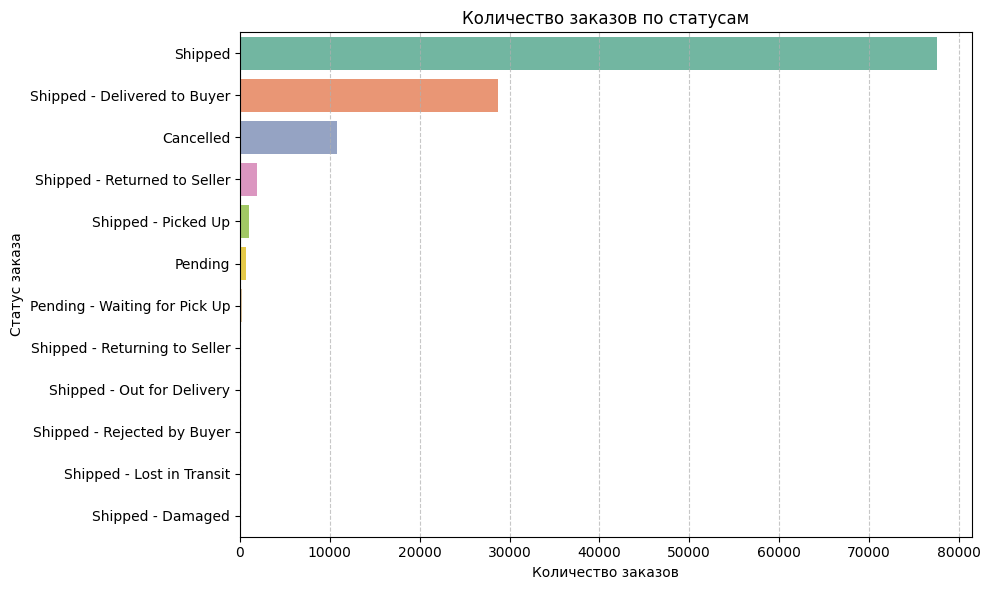

In [48]:
# Выведем линейчатую диаграмму с количеством заказов по статусам
status_counts = amazon_sale_clean['status'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(y=status_counts.index, x=status_counts.values, palette='Set2')
plt.title('Количество заказов по статусам')
plt.xlabel('Количество заказов')
plt.ylabel('Статус заказа')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()

Мы видим, что большинство заказов были доставлены (Shipped и Shipped - Delivered to Buyer).\
Около 10000 заказов отменено.\
Остальные статусы занимают около 2% данных. Для целей нашего исследования мы можем ими пренебречь.

Уберём отменённые заказы и посчитаем.

In [49]:
# Посчитаем количество заказов, которые были успешно доставлены через Amazon

order_count = amazon_sale_clean.loc[amazon_sale_clean['status'].isin(['Shipped', 'Shipped - Delivered to Buyer']), 'order_id'].nunique()
print(f"Через amazon было успешно доставлено {order_count:,.0f} заказов".replace(',', ' '));

# и количество отмененных заказов
cancelled_order_count = amazon_sale_clean.loc[amazon_sale_clean['status'] == 'Cancelled', 'order_id'].nunique()
print(f"{cancelled_order_count:,.0f} заказов было отменено".replace(',', ' '));

Через amazon было успешно доставлено 99 258 заказов
9 956 заказов было отменено


#### Сумма продаж

Посмотрим на сумму продаж

In [50]:
# Посчитаем сумму продаж полученных через Amazon
# Сумма продаж по статусам "Shipped" и "Shipped - Delivered to Buyer"
sales_sum = amazon_sale_clean.loc[amazon_sale_clean['status'].isin(['Shipped', 'Shipped - Delivered to Buyer']), 'amount'].sum()
print(f"Через amazon было продано товаров на {sales_sum:,.0f} рупий".replace(',', ' '));

Через amazon было продано товаров на 68 957 423 рупий


#### Средний чек и медиана

Чтобы посчитать средний чек разделим сумму продаж на количество заказов

In [51]:
# Посчитаем средний чек
average_order_value = sales_sum / order_count if order_count > 0 else 0
print(f"Средний чек через amazon {average_order_value:,.2f} рупий".replace(',', ' '));

Средний чек через amazon 694.73 рупий


Мы видим достаточно невысокий средний чек, почти 700 рупий.\
Посмотрим медиану.

In [52]:
# Посчитаем медиану суммы заказов
median_order_value = (
    amazon_sale_clean.loc[amazon_sale_clean['status'].isin(['Shipped', 'Shipped - Delivered to Buyer'])]
    .groupby('order_id')['amount'].sum().median() if order_count > 0 else 0
)
print(f"Медиана суммы заказов через amazon: {median_order_value:,.2f}₹".replace(',', ' '));

Медиана суммы заказов через amazon: 635.00₹


Мы видим, что большой разницы между средним и медианой нет.\
Посмотрим на ящик с усами сумм заказов.

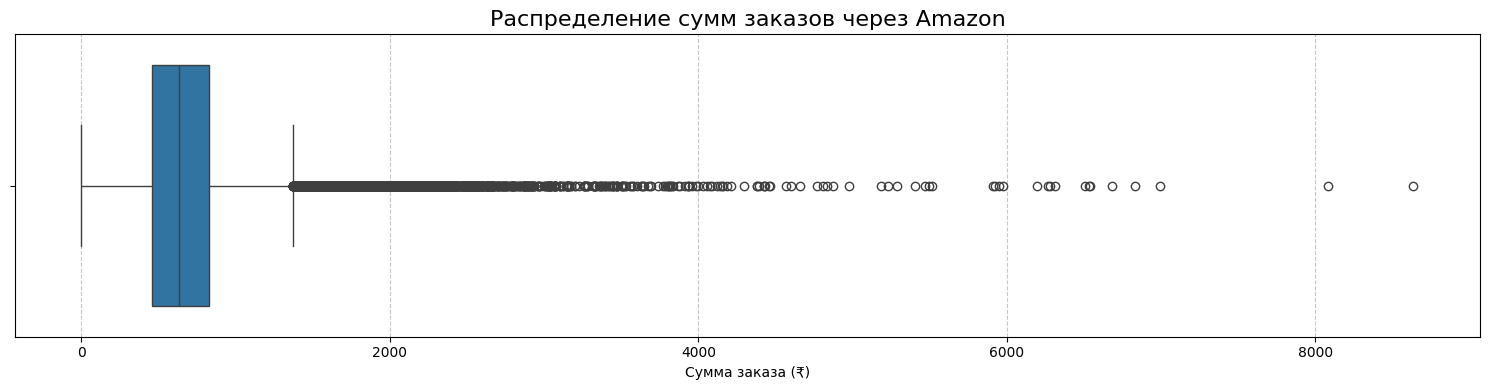

In [53]:
# Построим ящик с распределением сумм заказов
delivered_orders = amazon_sale_clean.loc[amazon_sale_clean['status'].isin(['Shipped', 'Shipped - Delivered to Buyer'])].groupby('order_id')['amount'].sum()

plt.figure(figsize=(15, 4))
sns.boxplot(
    x=delivered_orders,
)
plt.title('Распределение сумм заказов через Amazon', fontsize=16)
plt.xlabel('Сумма заказа (₹)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Суммы заказов не превышают 9000₹. Выбросы, судя по распределению, начинаются с 1500.\
Рассмотрим ящик более подробно, ограничив ось X.

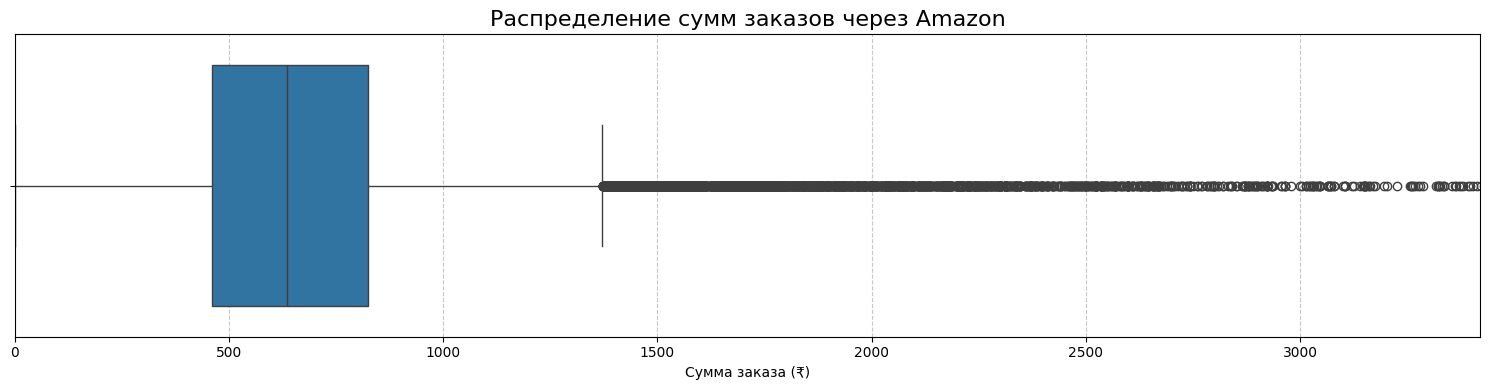

In [54]:
# Построим ящик с распределением сумм заказов
plt.figure(figsize=(15, 4))
sns.boxplot(
    x=delivered_orders,
)
plt.title('Распределение сумм заказов через Amazon', fontsize=16)
plt.xlabel('Сумма заказа (₹)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
# Уменьшим предел по оси X для лучшего отображения по квантилю 0,999
plt.xlim(0, delivered_orders.quantile(0.999))
plt.show()

Мы видим, что основная масса заказов (между усами) имеет сумму меньше 1400 рупий.\
Большинство (50%) в рамках 450-800 рупий.

In [55]:
# посмотрим статистику по суммам заказов
print("Статистика по суммам заказов:")

delivered_orders.describe()

Статистика по суммам заказов:


count   99258.00
mean      694.73
std       368.13
min         0.00
25%       459.00
50%       635.00
75%       824.00
max      8636.00
Name: amount, dtype: float64

#### Количество уникальных товаров

Посчитаем количество уникальных товаров, категорий.

In [56]:
# Посчитаем количество уникальных товаро (SKU) и категорий
unique_skus = amazon_sale_clean['sku'].nunique()
print(f"Количество уникальных товаров (SKU): {unique_skus}")

unique_categories = amazon_sale_clean['category'].nunique()
print(f"Количество уникальных категорий: {unique_categories}")

# Выведем список уникальных категорий
unique_categories_list = amazon_sale_clean['category'].unique()
print("Список уникальных категорий:")
for category in unique_categories_list:
    print(f"- {category}")

Количество уникальных товаров (SKU): 7157
Количество уникальных категорий: 9
Список уникальных категорий:
- Set
- kurta
- Western Dress
- Top
- Ethnic Dress
- Bottom
- Saree
- Blouse
- Dupatta


У нас 9 категорий одежды, в которых 7157 наименований товаров.

#### **Выводы:** 
- У нас продажи через Amazon одежды в Индии за апрель-июнь 2022 года;
- Более 7000 наименований товаров разделены на 9 категорий;
- Около 100 тысяч доставленных заказов, 10 тысяч отмененных;
- Успешно доставлено товаров на 70 млн рупий;
- Медиана суммы заказов 635₹, средняя сумма 695₹;



### Исследовательский анализ данных

Динамика продаж:
- Построить график выручки по месяцам и неделям.
- Построить график количества заказов по времени.
- Посмотреть сезонность (например, по месяцам или дням недели).


#### Динамика выручки по месяцам и неделям

Добавим столбец с месяцем и неделей

In [57]:
# Добавляем новый столбец с округлением до месяца
amazon_sale_clean['month'] = amazon_sale_clean['date'].dt.to_period('M')

# Группируем продажи по месяцам
amazon_month_sales = amazon_sale_clean.groupby(by='month', as_index=False)['amount'].sum()

amazon_month_sales

,month,amount
0,2022-03,101683.85
1,2022-04,28831249.32
2,2022-05,26218378.75
3,2022-06,23420060.38


<Figure size 1200x600 with 0 Axes>

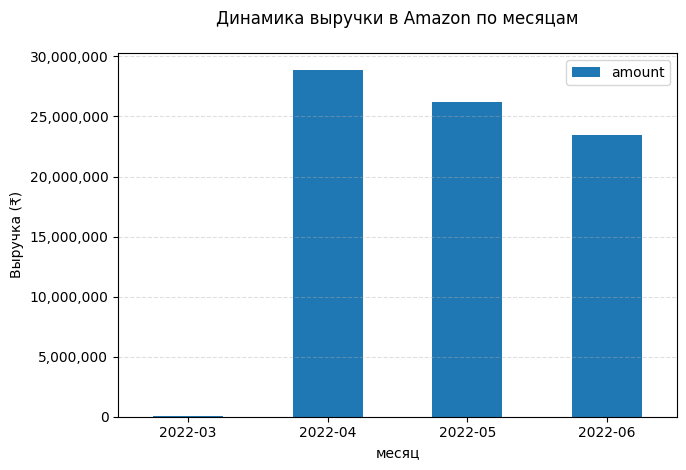

In [58]:
# Построим график динамики выручки по месяцам
plt.figure(figsize=(12, 6))
amazon_month_sales.plot(
    'month',
    'amount',
    kind='bar',
    )

plt.xlabel('месяц')
plt.ylabel('Выручка (₹)')
plt.title('Динамика выручки в Amazon по месяцам\n')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')); # Формат без экспоненты
plt.show();

C апреля по июнь продажи снизились с 28 до 24 миллионов рупий.

In [59]:
# Создаем колонку "неделя"
amazon_sale_clean['week'] = amazon_sale_clean['date'].dt.to_period('W')


# Группируем по неделям и суммируем продажи
amazon_week_sales = amazon_sale_clean.groupby(by='week', as_index=False)['amount'].sum()

amazon_week_sales

,week,amount
0,2022-03-28/2022-04-03,2892027.36
1,2022-04-04/2022-04-10,6694655.95
2,2022-04-11/2022-04-17,6900348.42
3,2022-04-18/2022-04-24,7060442.00
4,2022-04-25/2022-05-01,6465416.96
5,2022-05-02/2022-05-08,7186304.94
6,2022-05-09/2022-05-15,5364728.55
7,2022-05-16/2022-05-22,5283050.33
8,2022-05-23/2022-05-29,5583804.55
9,2022-05-30/2022-06-05,6168601.21


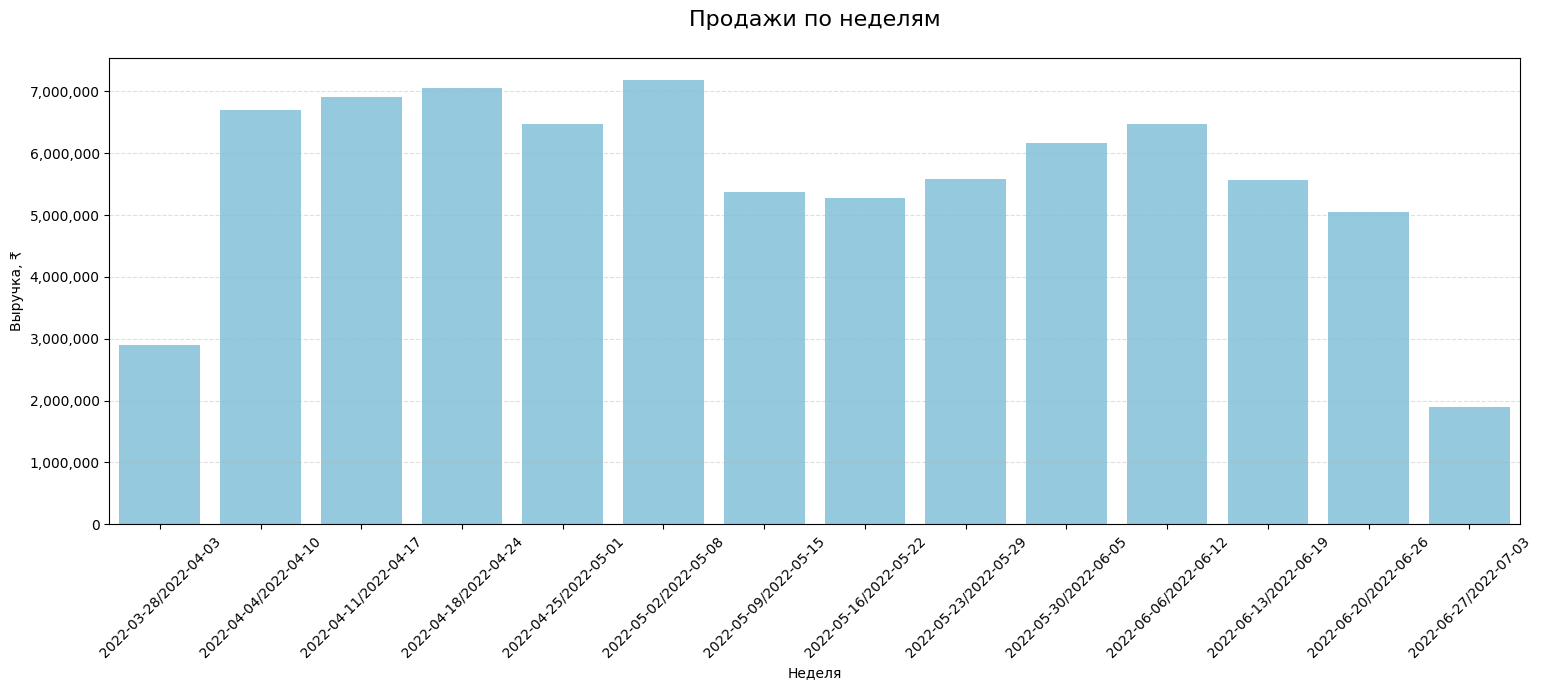

In [60]:
plt.figure(figsize=(15, 7))

sns.barplot(
    data=amazon_week_sales,
    x='week',
    y='amount',
    color='skyblue'
)

plt.xticks(rotation=45)
plt.title('Продажи по неделям\n', fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.xlabel('Неделя')
plt.ylabel('Выручка, ₹')

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')); # Формат без экспоненты
plt.show()

Выводы по диаграмме:
- продажи в апреле и первой неделе мая растут, затем резкое снижение и снова рост к концу месяца. Возможно, менеджеры по продажам стараются закрыть планы в конце месяца, либо сезонность товаров;
- продажи в мае-июне ниже, чем продажи в апреле.
- первую и последнюю недели графика не принимаем в расчет, неполные данные.

#### Динамика заказов по месяцам и неделям

Посмотрим, как менялось количество заказов по месяцам

<Figure size 1200x600 with 0 Axes>

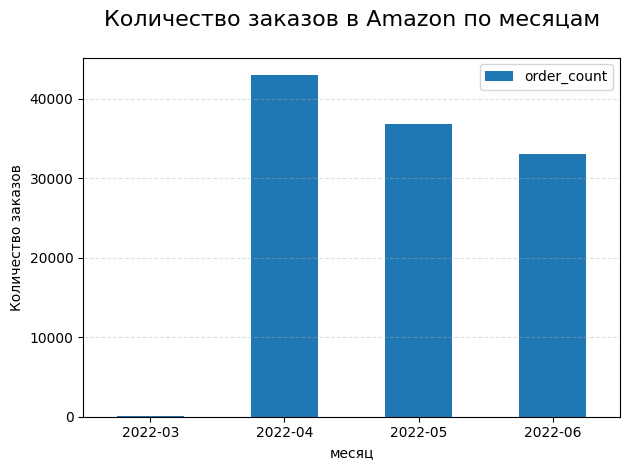

In [61]:
# Сгруппируем заказы по месяцам и посчитаем количество заказов
amazon_month_orders = amazon_sale_clean.groupby(by='month', as_index=False)['order_id'].nunique()
# Переименуем столбец для ясности
amazon_month_orders.rename(columns={'order_id': 'order_count'}, inplace=True)
# Построим график количества заказов по месяцам
plt.figure(figsize=(12, 6))
amazon_month_orders.plot(
    'month',
    'order_count',
    kind='bar',
)

# Настроим отображение графика
plt.xlabel('месяц') # подпись оси X
plt.ylabel('Количество заказов') # подпись оси Y
plt.title('Количество заказов в Amazon по месяцам\n', fontsize=16) # заголовок графика
# Уберем наклон оси X
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Количество заказов с апреля по июнь снизилось с 43 до 33 тысяч.

#### Топ-10 категорий по выручке и количеству продаж.

Посмотрим, на Топ категорий по выручке и количеству продаж.

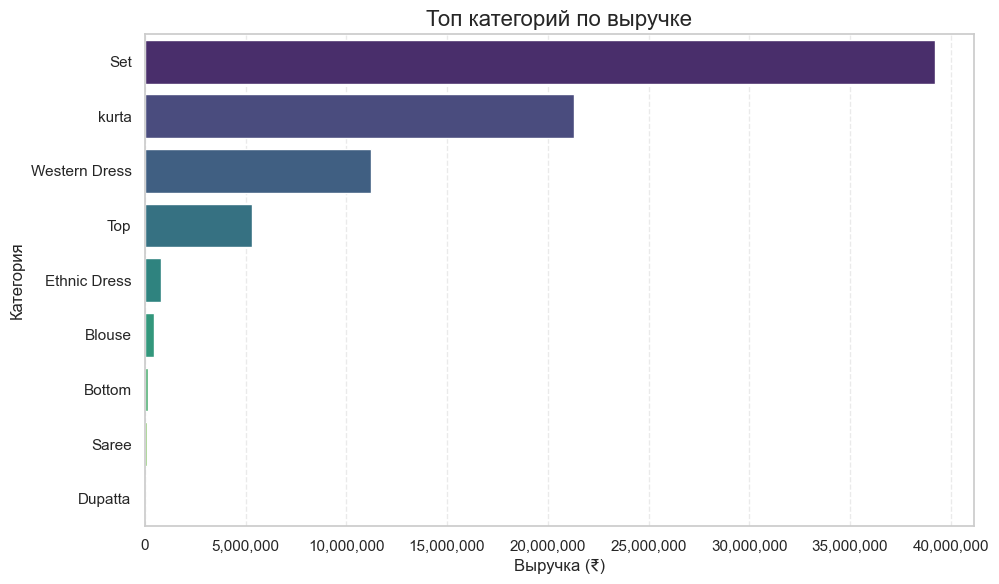

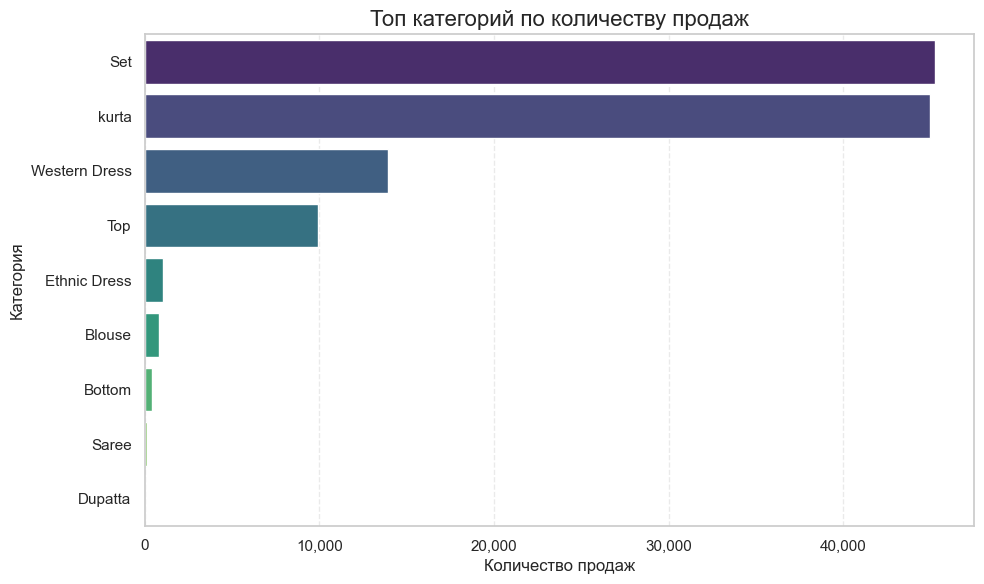

In [62]:
# Устанавливаем общий стиль графиков
sns.set(style='whitegrid')

# Топ-10 категорий по выручке (горизонтальная диаграмма)
top_categories_revenue = amazon_sale_clean.groupby('category')['amount'].sum().nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    y=top_categories_revenue.index,  # категории по оси Y
    x=top_categories_revenue.values,  # выручка по оси X
    palette='viridis'
)
plt.title('Топ категорий по выручке', fontsize=16)
plt.xlabel('Выручка (₹)')
plt.ylabel('Категория')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()


# Топ-10 категорий по количеству продаж (горизонтальная диаграмма)
top_categories_sales = amazon_sale_clean.groupby('category')['qty'].sum().nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    y=top_categories_sales.index,
    x=top_categories_sales.values,
    palette='viridis'
)
plt.title('Топ категорий по количеству продаж', fontsize=16)
plt.xlabel('Количество продаж')
plt.ylabel('Категория')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

Мы наблюдаем, что по выручке около половины продаж приносят комплекты (39 млн ₹). Если посмотреть на количество проданных единиц, то комплектов продается примерно столько же, сколько и курт. Следовательно, сеты стоят дороже примерно на 80-90%.

Третьей по популярности является западная одежда. Ее продано 14 тысяч штук на 11 млн рупий.

#### Топ-10 товаров по выручке и количеству продаж.

Посмотрим, на Топ товаров по выручке и количеству продаж.

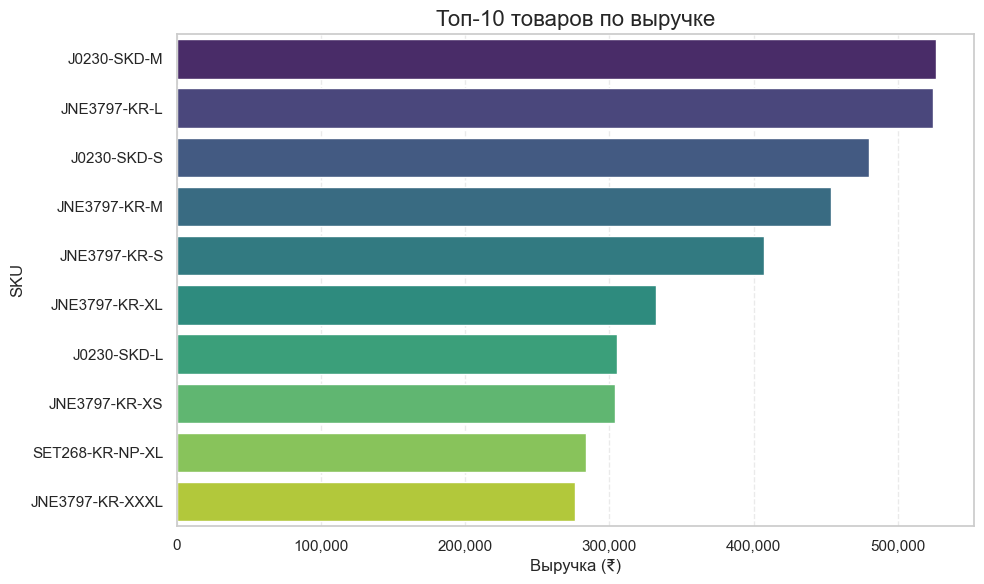

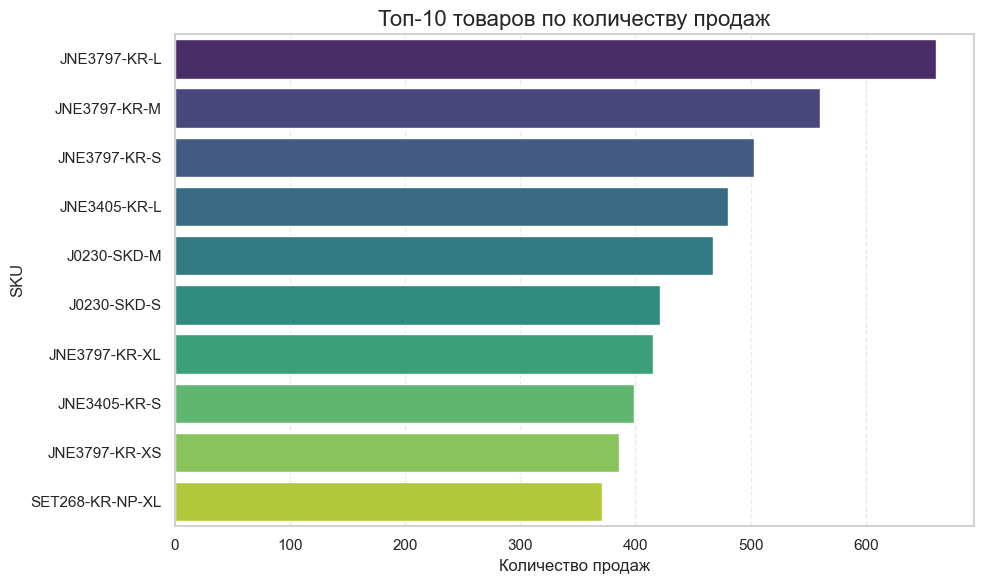

In [63]:
# Топ-10 товаров (SKU) по выручке
top_skus_revenue = amazon_sale_clean.groupby('sku')['amount'].sum().nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    y=top_skus_revenue.index,
    x=top_skus_revenue.values,
    palette='viridis'
)
plt.title('Топ-10 товаров по выручке', fontsize=16)
plt.xlabel('Выручка (₹)')
plt.ylabel('SKU')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()


# Топ-10 товаров по количеству продаж
top_skus_sales = amazon_sale_clean.groupby('sku')['qty'].sum().nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    y=top_skus_sales.index,
    x=top_skus_sales.values,
    palette='viridis'
)
plt.title('Топ-10 товаров по количеству продаж', fontsize=16)
plt.xlabel('Количество продаж')
plt.ylabel('SKU')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

Мы видим в топе товары J0230 и JNE3797, разных расцветок и размеров. В основном S, L, M.

Между позициями в топе нет критического разрыва, товары равномерно представлены.

In [64]:
# Посмотрим на товары, которые содержат J0230 или JNE3797 в SKU
sku_filter = amazon_sale_clean['sku'].str.contains('J0230|JNE3797', case=False, na=False)
# Выведем отфильтрованные товары
filtered_skus = amazon_sale_clean[sku_filter]

filtered_skus

,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,promotion_status,month,week
46,408-3917043-5314763,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,J0230,J0230-SKD-L,Set,L,B08XNDL1DL,Shipped,1,INR,1146.00,ONGOLE,ANDHRA PRADESH,523001,IN,NaN,False,Без промо,2022-04,2022-04-25/2022-05-01
154,171-3625443-6505905,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3797,JNE3797-KR-L,Western Dress,L,B09SDXFFQ1,Shipped,1,INR,725.00,KALAMASSERY,KERALA,682021,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Промо применено,2022-04,2022-04-25/2022-05-01
180,407-5875767-6399551,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,J0230,J0230-SKD-S,Set,S,B08XNJ19QH,Shipped,1,INR,1112.00,HYDERABAD,TELANGANA,500085,IN,NaN,False,Без промо,2022-04,2022-04-25/2022-05-01
248,407-6146457-8788352,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3797,JNE3797-KR-M,Western Dress,M,B09SDY8DCT,Shipped,1,INR,725.00,GAYA,BIHAR,823001,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Промо применено,2022-04,2022-04-25/2022-05-01
341,402-1572540-8678700,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3797,JNE3797-KR-M,Western Dress,M,B09SDY8DCT,Shipped,1,INR,725.00,KOLKATA,WEST BENGAL,700050,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Промо применено,2022-04,2022-04-25/2022-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128859,405-6870909-7366760,2022-06-01,Shipped,Amazon,Amazon.in,Expedited,JNE3797,JNE3797-KR-XXXL,Western Dress,3XL,B09SDY4VDC,Shipped,1,INR,771.00,TURA,MEGHALAYA,794001,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Промо применено,2022-06,2022-05-30/2022-06-05
128868,403-9524128-9243508,2022-06-01,Cancelled,Merchant,Amazon.in,Standard,JNE3797,JNE3797-KR-XL,Western Dress,XL,B09SDXRYBG,Cancelled,0,INR,734.29,Barabanki,UTTAR PRADESH,225001,IN,NaN,False,Без промо,2022-06,2022-05-30/2022-06-05
128904,171-2686043-8605144,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,J0230,J0230-SKD-XL,Set,XL,B08XNJ8P3S,Shipped,1,INR,1349.00,PUNE,MAHARASHTRA,411002,IN,NaN,False,Без промо,2022-05,2022-05-30/2022-06-05
128950,402-8261465-0622733,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,J0230,J0230-SKD-M,Set,M,B08XNJG8B1,Shipped,1,INR,1349.00,RANCHI,JHARKHAND,834002,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Промо применено,2022-05,2022-05-30/2022-06-05


Мы видим, что в нашем топе товаров оказались комплекты и неожиданно западные платья (JNE3797). 3 варианта этого товара было продано в количестве более 500 штук каждое.

#### Распределение продаж по типам клиентов

Посмотрим, какую часть выручки мы получаем благодаря продажам бизнесу

Выручка по каналам продаж (B2B vs B2C):


b2b_label
B2B     591220.79
B2C   77980151.51
Name: amount, dtype: float64

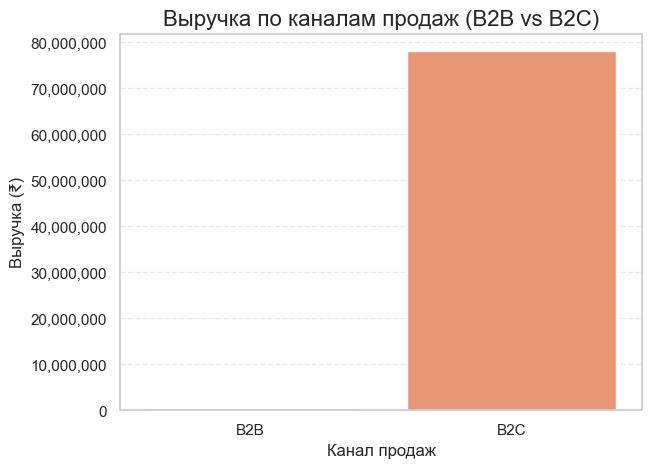

In [65]:
# Создадим копию с читаемыми метками
amazon_sale_clean['b2b_label'] = amazon_sale_clean['b2b'].map({True: 'B2B', False: 'B2C'})

# Группируем с новыми метками
b2b_b2c_revenue = amazon_sale_clean.groupby('b2b_label')['amount'].sum()

print("Выручка по каналам продаж (B2B vs B2C):")
display(b2b_b2c_revenue)

plt.figure(figsize=(6, 5))
sns.barplot(
    x=b2b_b2c_revenue.index,
    y=b2b_b2c_revenue.values,
    palette='Set2'
)
plt.title('Выручка по каналам продаж (B2B vs B2C)', fontsize=16)
plt.xlabel('Канал продаж')
plt.ylabel('Выручка (₹)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()


Судя по графику, продажи для бизнеса составляют несущественную часть - 0.5 млн рупий.\
Основной доход от конечного покупателя.

#### Доля возвратов и отмен

Посмотрим, какая доля заказов отменяется, сколько возвращается.

In [66]:
# Посчитаем доли заказов по статусам
# Сколько процентов заказов было успешно доставлено, сколько отменено
status_counts = amazon_sale_clean['status'].value_counts(normalize=True) * 100
# Выведем результаты
print("Доля заказов по статусам:")
display(status_counts)

Доля заказов по статусам:


status
Shipped                         64.04
Shipped - Delivered to Buyer    23.73
Cancelled                        8.88
Shipped - Returned to Seller     1.61
Shipped - Picked Up              0.80
Pending                          0.54
Pending - Waiting for Pick Up    0.23
Shipped - Returning to Seller    0.12
Shipped - Out for Delivery       0.03
Shipped - Rejected by Buyer      0.01
Shipped - Lost in Transit        0.00
Shipped - Damaged                0.00
Name: proportion, dtype: float64

Объединим Shipped и Shipped - Delivered to Buyer, Shipped - Picked Up,  в одну категорию - Shipped\
Shipped - Returned to Seller, Shipped - Returning to Seller - в категорию - Returned\
Shipped - Rejected by Buyer, Cancelled,  - в категорию - Cancelled\
Pending - Waiting for Pick Up, Pending, Shipped - Out for Delivery - в категорию - Pending\
Shipped - Lost in Transit, Shipped - Damaged - в окатегорию - Lost/Damaged\
Заменять будем в отдельном столбце, чтобы не потерять информацию

Доля заказов по статусам (после очистки):


status_cleaned
Shipped        88.57
Cancelled       8.89
Returned        1.73
Pending         0.80
Lost/Damaged    0.00
Name: proportion, dtype: float64

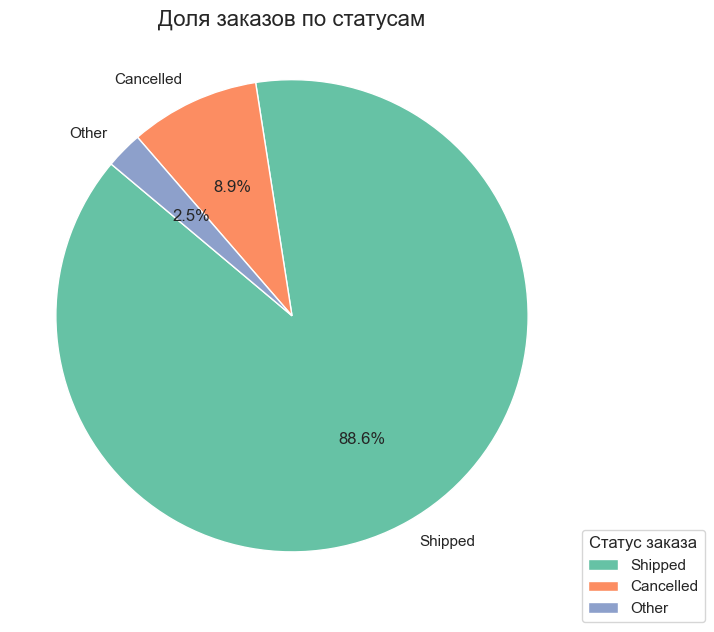

In [67]:
# Объединим похожие статусы для более удобного анализа
# Создадим новый столбец с очищенными статусами
amazon_sale_clean['status_cleaned'] = amazon_sale_clean['status'].replace({
    'Shipped': 'Shipped',
    'Shipped - Delivered to Buyer': 'Shipped',
    'Shipped - Picked Up': 'Shipped',
    'Shipped - Returned to Seller': 'Returned',
    'Shipped - Returning to Seller': 'Returned',
    'Shipped - Rejected by Buyer': 'Cancelled',
    'Cancelled': 'Cancelled',
    'Pending - Waiting for Pick Up': 'Pending',
    'Pending': 'Pending',
    'Shipped - Out for Delivery': 'Pending',
    'Shipped - Lost in Transit': 'Lost/Damaged',
    'Shipped - Damaged': 'Lost/Damaged'
})
# Считаем доли заказов по новым статусам
status_counts_cleaned = amazon_sale_clean['status_cleaned'].value_counts(normalize=True) * 100
# Выведем результаты
print("Доля заказов по статусам (после очистки):")
display(status_counts_cleaned)

# Построим круговую диаграмму с долями заказов по статусам
# Уберем категории с долями менее 2%
threshold = 2
other = status_counts_cleaned[status_counts_cleaned < threshold].sum()
main = status_counts_cleaned[status_counts_cleaned >= threshold]
status_counts_for_pie = main.copy()
status_counts_for_pie['Other'] = other

plt.figure(figsize=(6, 6))
plt.pie(
    status_counts_for_pie,
    labels=status_counts_for_pie.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', n_colors=len(status_counts_for_pie))
)
plt.axis('equal')
plt.title('Доля заказов по статусам\n', fontsize=16)
plt.tight_layout()
plt.legend(title='Статус заказа', loc='upper left', bbox_to_anchor=(1, 0.1))
plt.show()


Мы видим, что:
- основная часть заказов успешно доставлена покупателям;
- около 9% заказов отменено;
- возвраты составляют менее 2% заказов;
- доля заказов в статусе Утеряно/Повреждено и Ожидание незначительна - менее 1%;

В целом, процесс доставки стабилен, уровень возвратов и потерь минимален.

#### География продаж

In [68]:
# Посмотрим на продажи по регионам и городам ship_city и ship_state
# Сначала посмотрим на уникальные значения в этих столбцах
unique_ship_states = amazon_sale_clean['ship_state'].unique()
print("Уникальные штаты (ship_state):")
for state in unique_ship_states:
    print(f"- {state}")

Уникальные штаты (ship_state):
- MAHARASHTRA
- KARNATAKA
- PUDUCHERRY
- TAMIL NADU
- UTTAR PRADESH
- CHANDIGARH
- TELANGANA
- ANDHRA PRADESH
- RAJASTHAN
- DELHI
- HARYANA
- ASSAM
- JHARKHAND
- CHHATTISGARH
- ODISHA
- KERALA
- MADHYA PRADESH
- WEST BENGAL
- NAGALAND
- Gujarat
- UTTARAKHAND
- BIHAR
- JAMMU & KASHMIR
- PUNJAB
- HIMACHAL PRADESH
- ARUNACHAL PRADESH
- MANIPUR
- Goa
- MEGHALAYA
- GOA
- TRIPURA
- LADAKH
- DADRA AND NAGAR
- SIKKIM
- Delhi
- ANDAMAN & NICOBAR 
- Punjab
- Rajshthan
- Manipur
- rajasthan
- Odisha
- NL
- Bihar
- MIZORAM
- punjab
- New Delhi
- Rajasthan
- Punjab/Mohali/Zirakpur
- Puducherry
- delhi
- RJ
- Chandigarh
- orissa
- LAKSHADWEEP
- goa
- PB
- Arunachal Pradesh
- AR
- Pondicherry
- Sikkim
- Arunachal pradesh
- Nagaland
- bihar
- Mizoram
- rajsthan
- Orissa
- Rajsthan
- Meghalaya


Мы видим повторяющиеся значения, приведем все к одному формату

In [69]:
# Приведем названия штатов и городов к единому виду
def clean_location_name(name):
    """
    Приводит название региона или города к единому виду:
    - убирает пробелы в начале и конце
    - приводит к нижнему регистру
    - заменяет дефисы и пробелы на подчеркивания
    - удаляет всё, начиная с первой цифры (если цифра не в начале)
    """
    if not isinstance(name, str):
        return name

    cleaned = name.strip().lower().replace('-', '_')
    cleaned = re.sub(r'\s+', '_', cleaned)

    # Если цифра не на первом месте — обрезаем от первой цифры и далее
    match = re.search(r'\d', cleaned)
    if match and match.start() > 0:
        cleaned = cleaned[:match.start()]

    # Удалим завершающие/начальные подчёркивания и лишние повторения
    cleaned = re.sub(r'_+', '_', cleaned).strip('_')

    return cleaned
# Применим очистку к столбцам ship_state и ship_city
amazon_sale_clean['ship_state'] = amazon_sale_clean['ship_state'].apply(clean_location_name)
amazon_sale_clean['ship_city'] = amazon_sale_clean['ship_city'].apply(clean_location_name)
# Посмотрим на уникальные значения после очистки
unique_ship_states_cleaned = amazon_sale_clean['ship_state'].unique()
print("Уникальные штаты (ship_state) после очистки:")
for state in sorted(unique_ship_states_cleaned):
    print(f"- {state}")

Уникальные штаты (ship_state) после очистки:
- andaman_&_nicobar
- andhra_pradesh
- ar
- arunachal_pradesh
- assam
- bihar
- chandigarh
- chhattisgarh
- dadra_and_nagar
- delhi
- goa
- gujarat
- haryana
- himachal_pradesh
- jammu_&_kashmir
- jharkhand
- karnataka
- kerala
- ladakh
- lakshadweep
- madhya_pradesh
- maharashtra
- manipur
- meghalaya
- mizoram
- nagaland
- new_delhi
- nl
- odisha
- orissa
- pb
- pondicherry
- puducherry
- punjab
- punjab/mohali/zirakpur
- rajasthan
- rajshthan
- rajsthan
- rj
- sikkim
- tamil_nadu
- telangana
- tripura
- uttar_pradesh
- uttarakhand
- west_bengal


In [70]:
# Выведем список уникальных городов после очистки c сортировкой
unique_ship_cities_cleaned = amazon_sale_clean['ship_city'].unique()

print(f"Всего уникальных городов (ship_city): {len(unique_ship_cities_cleaned)}")
print(f"Уникальные города (ship_city) после очистки: {sorted(list(unique_ship_cities_cleaned))}")

Всего уникальных городов (ship_city): 6868
Уникальные города (ship_city) после очистки: ['(chikmagalur_disterict)._(n.r_pur_thaluku)', '(via_cuncolim)quepem,south_goa', ',hyderabad', ',raibarely_road_faizabad_(ayodhya)', '..katra', '.azamgarh', '.gannavaram', '1', '116_b._p._m._b_sarani,_uttarpara_kotrung', '147/19_b_keshab_chandra_sen_street_kolkata_nine_ma', '6th_mile_tadong', '7barasat', 'aalo', 'aamby_valley', 'abhayapuri', 'abhayapuri,_bongaigaon', 'abohar', 'abu_road', 'aburoad', 'achalpur', 'achampet', 'achanta', 'acharapakkam', 'achhnera', 'adajan_gam,_surat', 'adalaj', 'adambakkam', 'adampur', 'adapur', 'adarsh_nagar,_jaipur', 'adbhar', 'addakal', 'addanki', 'addanki_mandal_bapatl_district', 'addision_nagar,_mangadu', 'adichanalloor', 'adilabad', 'adimaly', 'adinad', 'adipur', 'adipur,_gandhidham', 'adityana', 'adityapur', 'adityapur/_jamshedpur', 'adoni', 'adoor', 'adoor,_vaddakkedathu_cavu', 'adra', 'adyal', 'afzalgarh', 'agar', 'agar_malwa', 'agarpara', 'agartala', 'agarwad

Мы получили более 7000 наименований городов, многие из которых повторяются.\
Чтобы объединить в автоматизированном режиме похожие, воспользуемся библиотекой `rapidfuzz` и функцией.

In [71]:
# Код для кластеризации похожих названий городов:

def cluster_similar_strings(strings, threshold=90):
    clusters = []
    used = set()

    for s in strings:
        if s in used:
            continue
        cluster = [s]
        used.add(s)

        matches = process.extract(s, strings, scorer=fuzz.ratio, limit=None)
        for match, score, _ in matches:
            if match not in used and score >= threshold:
                cluster.append(match)
                used.add(match)

        clusters.append(cluster)

    return clusters


In [72]:
# Применим кластеризацию к уникальным городам
unique_cities = amazon_sale_clean['ship_city'].dropna().unique()

clusters = cluster_similar_strings(unique_cities, threshold=85)

In [73]:
#  Создаём словарь замены (заменим на 1-е значение из кластера):
replacement_dict = {}
for cluster in clusters:
    main_name = cluster[0]
    for alt in cluster:
        replacement_dict[alt] = main_name


In [74]:
# Заменяем в датафрейме:
amazon_sale_clean['ship_city_clean'] = amazon_sale_clean['ship_city'].map(replacement_dict).fillna(amazon_sale_clean['ship_city'])
# Проверим, сколько уникальных городов осталось после очистки
unique_ship_cities_cleaned_after = amazon_sale_clean['ship_city_clean'].nunique()
print(f"Уникальных городов (ship_city_clean) после очистки: {unique_ship_cities_cleaned_after}")

Уникальных городов (ship_city_clean) после очистки: 5836


In [75]:
replacement_dict

{'mumbai': 'mumbai',
 'mumbai.': 'mumbai',
 'mumbai,': 'mumbai',
 'mmbai': 'mumbai',
 'mumba': 'mumbai',
 "mumbai's": 'mumbai',
 'bengaluru': 'bengaluru',
 'bengaluru;': 'bengaluru',
 'bengaluru,': 'bengaluru',
 'bengaluru.': 'bengaluru',
 'bengalur': 'bengaluru',
 'bengalure': 'bengaluru',
 'bangaluru': 'bengaluru',
 'navi_mumbai': 'navi_mumbai',
 'navi_mumbai,': 'navi_mumbai',
 'navimumbai': 'navi_mumbai',
 'puducherry': 'puducherry',
 'chennai': 'chennai',
 'chennai.': 'chennai',
 'chennnai': 'chennai',
 'chenai': 'chennai',
 'chenani': 'chennai',
 'ghaziabad': 'ghaziabad',
 'ghaziyabad': 'ghaziabad',
 'gaziabad': 'ghaziabad',
 'ghaziabadlpi': 'ghaziabad',
 'ghaziabad_up': 'ghaziabad',
 'chandigarh': 'chandigarh',
 'chandiagarh': 'chandigarh',
 'chandigar': 'chandigarh',
 'hyderabad': 'hyderabad',
 'hyderabad,': 'hyderabad',
 ',hyderabad': 'hyderabad',
 'hyderabad.': 'hyderabad',
 'hyderbad': 'hyderabad',
 'hydrabad': 'hyderabad',
 'hyderaba': 'hyderabad',
 'hyderabad_(': 'hyderabad

In [76]:
sorted(list(amazon_sale_clean['ship_city_clean'].unique()))

['(chikmagalur_disterict)._(n.r_pur_thaluku)',
 '(via_cuncolim)quepem,south_goa',
 ',raibarely_road_faizabad_(ayodhya)',
 '..katra',
 '1',
 '116_b._p._m._b_sarani,_uttarpara_kotrung',
 '147/19_b_keshab_chandra_sen_street_kolkata_nine_ma',
 '6th_mile_tadong',
 'aalo',
 'aamby_valley',
 'abhayapuri',
 'abhayapuri,_bongaigaon',
 'abohar',
 'abu_road',
 'achalpur',
 'achampet',
 'achanta',
 'acharapakkam',
 'achhnera',
 'adajan_gam,_surat',
 'adalaj',
 'adambakkam',
 'adampur',
 'adarsh_nagar,_jaipur',
 'adbhar',
 'addakal',
 'addanki',
 'addanki_mandal_bapatl_district',
 'addision_nagar,_mangadu',
 'adichanalloor',
 'adilabad',
 'adimaly',
 'adinad',
 'adipur,_gandhidham',
 'adityana',
 'adityapur',
 'adityapur/_jamshedpur',
 'adoni',
 'adoor',
 'adoor,_vaddakkedathu_cavu',
 'adyal',
 'afzalgarh',
 'agar_malwa',
 'agarpara',
 'agartala',
 'agarwada',
 'agatti',
 'agiripalle',
 'agra',
 'ahemadabad',
 'ahiwara',
 'ahmadnagar',
 'ahmadpur',
 'ahmedabad',
 'ahmedabadvasna',
 'ahore',
 'aiman

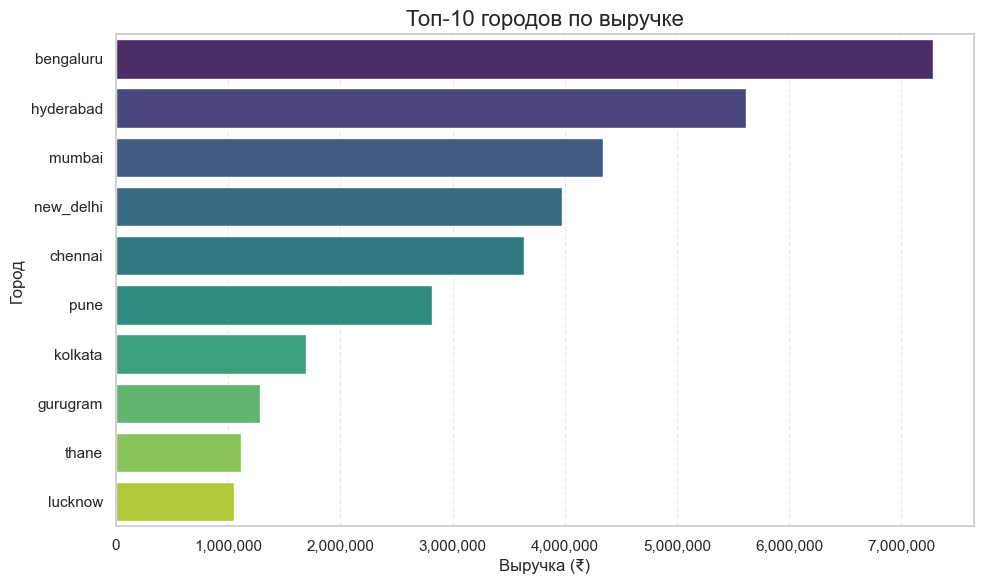

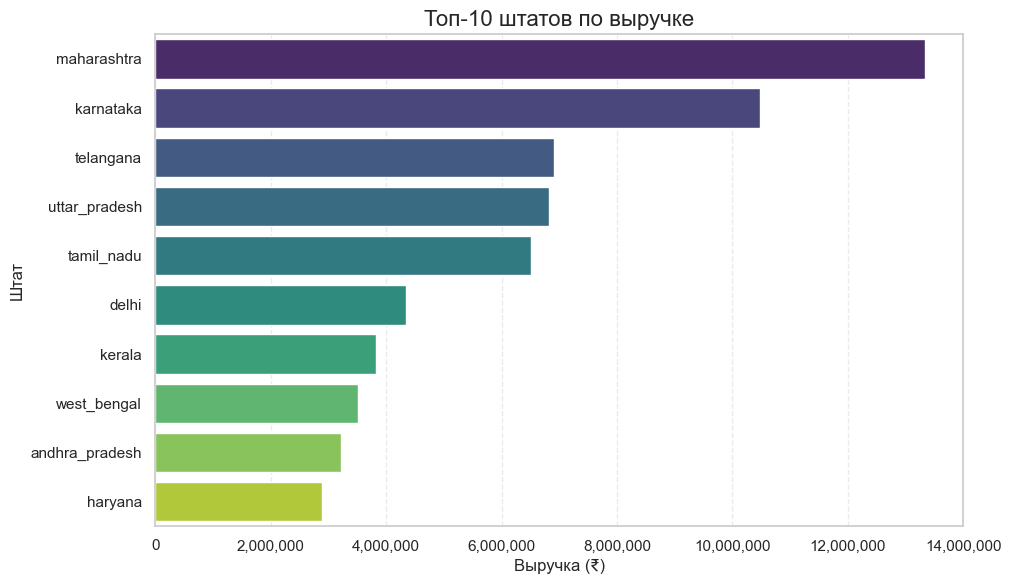

In [77]:
# Выведем топ-10 городов по выручке
top_cities_revenue = amazon_sale_clean.groupby('ship_city_clean')['amount'].sum().nlargest(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    y=top_cities_revenue.index,
    x=top_cities_revenue.values,
    palette='viridis'
)
plt.title('Топ-10 городов по выручке', fontsize=16)
plt.xlabel('Выручка (₹)')
plt.ylabel('Город')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

# Выведем топ-10 штатов по выручке
top_states_revenue = amazon_sale_clean.groupby('ship_state')['amount'].sum().nlargest(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    y=top_states_revenue.index,
    x=top_states_revenue.values,
    palette='viridis'
)
plt.title('Топ-10 штатов по выручке', fontsize=16)
plt.xlabel('Выручка (₹)')
plt.ylabel('Штат')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()


- Больше всего покупают в штатах Maharashtra, Karnataka - более 10 миллионов рупий выручки. Далее 3 штата по 7 миллионов - Telangana, Uttar Pradesh, Tamil Nadu;
- Среди городов выделяется Bengaluru (штат Karnataka), больше 7 миллионов. Далее Hyderabad c 5.5 млн.

#### Выводы по разделу:

- С апреля по июнь наблюдается снижение как общей выручки (с 28 до 24 млн ₹), так и количества заказов (с 43 до 33 тыс).
- Внутри месяца виден пик продаж в конце, что может указывать на выполнение планов или сезонность.
- Почти половину выручки приносят комплекты (сеты), которые продаются по более высокой цене по сравнению с куртами.
- Западная одежда занимает третье место по популярности — 14 тыс. продаж на 11 млн ₹.
- В топе продаж представлены как комплекты, так и западные платья (например, JNE3797), с равномерным распределением по позициям.
- Большинство популярных товаров представлены в нескольких размерах, преимущественно S, M и L.
- Продажи B2B (бизнесу) несущественны — около 0.5 млн ₹, основная выручка поступает от конечных покупателей.
- 88.6% заказов успешно доставлены, 8.9% отменены, 1.7% возвращены — доставка работает стабильно, уровень потерь и возвратов минимален.
- Первоначально было более 7000 уникальных названий городов, после очистки — 5836.
- Наибольшая выручка по штатам — Maharashtra и Karnataka (по 10+ млн ₹), затем Telangana, Uttar Pradesh, Tamil Nadu (по ~7 млн).
- Среди городов лидирует Bengaluru (7+ млн ₹), за ним Hyderabad (~5.5 млн).

# Проверка гипотез

### Гипотеза №1. Заказы с использованием промокодов дороже.

Проверим гипотезу:
- H0: Суммы заказов с использованием промокодов равны или меньше, чем без промокодов;
- H1: Суммы заказов с использованием промокодов больше, чем без промокодов

Нужно будет учесть размер совокупностей.

In [78]:
# Отбрасываем строки с нулевой суммой до агрегации
filtered_data = amazon_sale_clean[amazon_sale_clean['amount'] > 0]

# разделяем данные по сегментам промо-акций
promo_orders = (
    filtered_data[filtered_data['promotion_status'] == 'Промо применено']
    .groupby('order_id')['amount'].sum()
)

no_promo_orders = (
    filtered_data[filtered_data['promotion_status'] == 'Без промо']
    .groupby('order_id')['amount'].sum()
)

# проверяем размеры сегментов
print(f"Количество заказов с промо: {promo_orders.shape[0]}")
print(f"Количество заказов без промо: {no_promo_orders.shape[0]}")

Количество заказов с промо: 72406
Количество заказов без промо: 38265


In [79]:
# Описательная статистика для сумм заказов с промо
print('Описательная статистика сумм заказов:')
for segment, orders in zip(['С промо', 'Без промо'], [promo_orders, no_promo_orders]):
    print(f"\n{segment}:")
    print(orders.describe().to_string())

Описательная статистика сумм заказов:

С промо:
count   72406.00
mean      739.86
std       364.35
min       229.00
25%       499.00
50%       684.00
75%       855.00
max      8636.00

Без промо:
count   38265.00
mean      653.37
std       337.74
min       199.00
25%       432.00
50%       550.00
75%       788.00
max      8081.00


Мы видим, что в среднем заказы с промо имеют большую сумму, чем без промо. Теперь сравним распределения сумм заказов с и без промо.

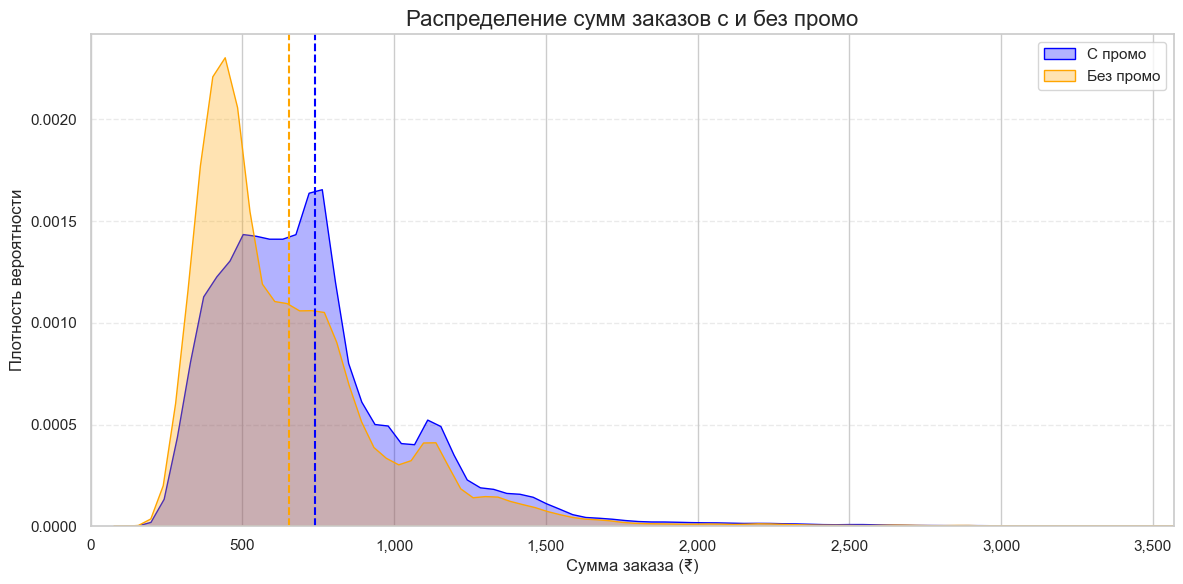

In [80]:
# Построим графики распределения сумм заказов с и без промо
plt.figure(figsize=(12, 6))
sns.kdeplot(
    promo_orders,
    label='С промо',
    color='blue',
    fill=True,
    alpha=0.3
)
sns.kdeplot(
    no_promo_orders,
    label='Без промо',
    color='orange',
    fill=True,
    alpha=0.3
)
plt.title('Распределение сумм заказов с и без промо', fontsize=16)
plt.xlabel('Сумма заказа (₹)')
plt.ylabel('Плотность вероятности')
# добавим ограниечения по оси X
plt.xlim(0, promo_orders.quantile(0.999))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))  # Формат без экспоненты
# Добавим вертикальные линии для средних значений
plt.axvline(promo_orders.mean(), color='blue', linestyle='--', label=f'Среднее с промо: ₹{promo_orders.mean():.0f}')
plt.axvline(no_promo_orders.mean(), color='orange', linestyle='--', label=f'Среднее без промо: ₹{no_promo_orders.mean():.0f}')
plt.show()

График показывает, что заказы с промо-кодом чаще бывают на большие суммы, чем без промо, и их распределение "размазано" правее.

Для проведения t-теста должно быть выполнено несколько условий:
- Данные должны быть независимыми: каждая группа должна представлять собой отдельную выборку.
- Данные должны быть нормально распределены: для больших выборок (обычно n > 30) это условие менее критично из-за центральной предельной теоремы.
- Дисперсии в группах должны быть равны: это условие можно проверить с помощью теста Левена.

In [81]:
# Проверим, есть ли пересечения между заказами с промо и без промо
# Получим множества order_id из обеих выборок
promo_ids = set(promo_orders.index)
no_promo_ids = set(no_promo_orders.index)

# Пересечение
intersection = promo_ids.intersection(no_promo_ids)

# Проверим результат
print(f"Общее количество заказов с пересечением: {len(intersection)}")
if len(intersection) > 0:
    print("Вот несколько примеров пересекающихся order_id:")
    print(list(intersection)[:10])
else:
    print("Пересечений нет — выборки независимы.")


Общее количество заказов с пересечением: 10
Вот несколько примеров пересекающихся order_id:
['405-9696754-8726728', '402-5856264-1985921', '407-7832236-3117154', '406-4747000-9163551', '171-1276032-4353917', '406-4121271-9465913', '407-5640715-7774715', '408-9039765-2337924', '402-0525616-3729136', '406-8807842-4700367']


Мы получили 10 заказов, которые есть в обеих группах.\
Удалим их из групп.

In [82]:
# Удалим пересекающиеся заказы из выборки с промо
promo_orders = promo_orders[~promo_orders.index.isin(intersection)]
# Удалим пересекающиеся заказы из выборки без промо
no_promo_orders = no_promo_orders[~no_promo_orders.index.isin(intersection)]

# Проверим, что пересечений больше нет
intersection_after = promo_orders.index.intersection(no_promo_orders.index)
print(f"Количество пересечений после удаления: {len(intersection_after)}")

Количество пересечений после удаления: 0


Так как у нас большие группы (n>30000), то по ЦПТ мы можем не проверять совокупности на нормальность.

Проверим дисперсии по тесту Левена.

In [83]:
# Тест Левена для проверки равенства дисперсий
levene_test = levene(promo_orders, no_promo_orders)
print(f"Результаты теста Левена: statistic={levene_test.statistic:.4f}, p-value={levene_test.pvalue:.4f}")
if levene_test.pvalue < 0.05:
    print("Дисперсии различаются (p < 0.05), поэтому будем использовать equal_var=False в t-тесте")
else:
    print("Дисперсии равны (p >= 0.05)")

Результаты теста Левена: statistic=49.8025, p-value=0.0000
Дисперсии различаются (p < 0.05), поэтому будем использовать equal_var=False в t-тесте


In [84]:
# установим уровень значимости
alpha = 0.05

# Используем t-тест для независимых выборок
t_stat, p_value = ttest_ind(
    promo_orders,
    no_promo_orders,
    equal_var=levene_test.pvalue >= 0.05,  # используем результат теста Левена
    alternative='greater'  # односторонний тест на promo > no_promo
)

print(f"t-статистика: {t_stat:.3f}")
print(f"p-значение: {p_value:.4f}")

# Интерпретация результата
if p_value < alpha:
    print("Отклоняем H₀: средний чек с промо действительно выше.")
else:
    print("Не удалось отклонить H₀: нет достаточных оснований считать, что с промо средний чек выше.")

t-статистика: 39.565
p-значение: 0.0000
Отклоняем H₀: средний чек с промо действительно выше.


**Вывод:** Мы подтвердили гипотезу, что заказы с использованными промокодами и акциями больше по сумме, чем без промокодов.\
При прочих равных мы можем предположить, что использование промокодов увеличивает продажи. 

### Гипотеза №2. Товары со скидкой дешевле, чем товары без скидки

Проверим гипотезу о том, что цена товара с промокодом выше, чем без промокода:
- H0 - Цена товара с промокодом равна или больше цены без промокода
- H1 - Цена товара с промокодом меньше цены без промокода

Уберем товары с нулевыми ценами

In [85]:
# Разделим данные на сегменты с промо и без промо для дальнейшего анализа
# Убираем строки с нулевой или отрицательной ценой
sku_promo = amazon_sale_clean[
    (amazon_sale_clean['promotion_status'] == 'Промо применено') &
    (amazon_sale_clean['amount'] > 0)
]

sku_no_promo = amazon_sale_clean[
    (amazon_sale_clean['promotion_status'] == 'Без промо') &
    (amazon_sale_clean['amount'] > 0)
]

# Проверим, есть ли общие SKU в обоих сегментах
common_skus = set(sku_promo['sku']).intersection(set(sku_no_promo['sku']))

print(f"Количество общих SKU: {len(common_skus)}")

# Создадим датафреймы только с общими SKU
sku_promo_common = sku_promo[sku_promo['sku'].isin(common_skus)]
sku_no_promo_common = sku_no_promo[sku_no_promo['sku'].isin(common_skus)]

# Посчитаем средние цены для каждого SKU в обоих сегментах
promo_prices = sku_promo_common.groupby('sku')['amount'].mean()
no_promo_prices = sku_no_promo_common.groupby('sku')['amount'].mean()

# Выведем описательную статистику по ценам
print("Описательная статистика цен:")
for segment, prices in zip(['С промо', 'Без промо'], [promo_prices, no_promo_prices]):
    print(f"\n{segment}:")
    print(prices.describe().to_string())

# Создадим датафрейм для сравнения цен с и без промо
sku_price_comparison = pd.DataFrame({
    'price_with_promo': promo_prices,
    'price_without_promo': no_promo_prices
}).dropna()


Количество общих SKU: 5126
Описательная статистика цен:

С промо:
count   5126.00
mean     626.74
std      270.34
min      229.00
25%      427.70
50%      568.33
75%      764.25
max     2598.00

Без промо:
count   5126.00
mean     620.30
std      266.99
min      218.10
25%      424.18
50%      563.00
75%      759.00
max     2598.00


In [86]:
# Тест Левена для проверки равенства дисперсий
levene_test = levene(promo_prices, no_promo_prices)
print(f"Результаты теста Левена: statistic={levene_test.statistic:.4f}, p-value={levene_test.pvalue:.4f}")
if levene_test.pvalue < 0.05:
    print("Дисперсии различаются (p < 0.05), поэтому будем использовать equal_var=False в t-тесте")
else:
    print("Дисперсии равны (p >= 0.05)")

# Независимые выборки
t_stat, p_value = ttest_ind(
    sku_price_comparison['price_with_promo'],
    sku_price_comparison['price_without_promo'],
    equal_var=levene_test.pvalue >= 0.05,  # используем результат теста Левена
    alternative='less'  # Односторонний тест
)

print(f"t-статистика: {t_stat:.3f}")
print(f"p-значение: {p_value:.4f}")

if p_value < 0.05:
    print("Отклоняем H₀: цена с промо действительно ниже.")
else:
    print("Не удалось отклонить H₀: цены на товар с промокодом не ниже.")


Результаты теста Левена: statistic=0.0154, p-value=0.9013
Дисперсии равны (p >= 0.05)
t-статистика: 1.213
p-значение: 0.8875
Не удалось отклонить H₀: цены на товар с промокодом не ниже.


**Вывод:** Мы не смогли подтвердить гипотезу, что товары с промокодами дешевле, чем без промокодов, в данном магазине.

### Выводы по разделу:

- Подтверждена гипотеза: заказы с промокодами и акциями в среднем дороже, чем без них — это указывает на их эффективность для увеличения выручки.
- Не подтверждена гипотеза, что товары с промокодами дешевле — вероятно, скидки применяются к более дорогим товарам.

**Рекомендации:**

- Продолжать использовать промокоды как инструмент стимулирования продаж, особенно для товаров с высокой маржинальностью.

# Выводы и рекомендации

##  Выводы

- Продажи одежды через Amazon India за апрель–июнь 2022 года составили более **70 млн ₹** с **около 100 тыс. доставленных заказов**.
- За этот период наблюдается **снижение выручки и количества заказов**, особенно в мае–июне.
- Внутри месяца виден **пик заказов в конце** — возможно, из-за выполнения планов продаж или сезонности.
- Почти **половину выручки приносят комплекты** (сеты), хотя их продаётся столько же, сколько и курт — комплекты стоят на **80–90% дороже**.
- **Западная одежда** занимает третье место по популярности (14 тыс. продаж на 11 млн ₹); выделяется модель **JNE3797** в размерах S–L.
- В топе продаж нет резких перекосов — позиции представлены равномерно.
- **88.6% заказов доставлены**, 8.9% отменены, 1.7% возвращены — **процесс логистики стабилен**, уровень потерь и возвратов минимален.
- Основной доход поступает от **частных лиц**, продажи B2B составляют менее 1% выручки.
- После очистки данных — **5836 уникальных городов** (из 7000+), что улучшает геоаналитику.
- **Лидеры по выручке среди штатов** — Maharashtra и Karnataka (по 10+ млн ₹), далее Telangana, Uttar Pradesh и Tamil Nadu (~7 млн ₹).
- Среди городов лидирует **Bengaluru** (7+ млн ₹), затем **Hyderabad** (~5.5 млн ₹).
- Подтверждена гипотеза: **промокоды увеличивают сумму заказа** — их применение связано с более дорогими товарами.
- Не подтверждена гипотеза, что товары с промокодами дешевле — скидки чаще применяются к более дорогим позициям.

## Рекомендации

- **Продолжать использовать промокоды** как инструмент увеличения выручки, особенно на товары с высокой маржинальностью.
- Активизировать маркетинговые кампании в **конце месяца**, учитывая пиковые периоды продаж.
- Сосредоточиться на категориях, приносящих наибольшую выручку — **комплекты и западная одежда** — с акцентом на разнообразие размеров.